# Customer Reactivation Prediction Model

**Goal:** Predict which inactive customers are most likely to come back if contacted, so the marketing budget can be focused on the best targets.

**Output:** A scored and prioritised client list ready for campaign planning.

## Imports & Setup

Loads all required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, RobustScaler)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from scipy.stats import ks_2samp

import shap

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## Data Loading

Loads two CSV files: client data (one row per customer) and sales data (one row per transaction).

In [2]:
clients = pd.read_csv(
    './TOOL_CLIENT.csv',
    dtype={'CLIENT_ID': str}
)

sales = pd.read_csv(
    './TOOL_SALES.csv',
    dtype={'CLIENT_ID': str, 'ITEM_ID': str, 'CANCELLED': str},
    low_memory=False
)

initial_number_of_sales = len(sales)
initial_number_of_clients = len(clients)

print(f'Sales  : {sales.shape[0]:,} rows × {sales.shape[1]} cols')
print(f'Clients: {clients.shape[0]:,} rows × {clients.shape[1]} cols')


Sales  : 2,050,449 rows × 10 cols
Clients: 93,257 rows × 8 cols


## Data Cleaning & Type Casting

Converts columns to correct data types (dates, categories, flags) and fills missing regions with "unknown".

In [3]:
clients["CLIENT_CREATE DATE"] = pd.to_datetime(clients["CLIENT_CREATE DATE"])
clients["REGION"]             = clients["REGION"].fillna("unknown").astype("string")
clients["ECO_POT_CLASS"]      = clients["ECO_POT_CLASS"].astype("string")
clients["RISK_CAT"]           = clients["RISK_CAT"].astype("string")
sales["UNIT"]                 = sales["UNIT"].astype("string")
sales["FAMILY_CODE"]          = sales["FAMILY_CODE"].astype("string")
sales["YYYYMM"]               = pd.to_datetime(sales["YYYYMM"], format="%Y%m")
sales["SALES_CHANNEL"]        = sales["SALES_CHANNEL"].astype("string")
sales['CANCELLED']            = (sales['CANCELLED'] == 'X').astype(int)

## Cleaning Transactions — Negative & Zero Values

Removes non-productive transactions (returns, zero-value rows) while preserving the **count** of these per client as behavioural features. Only real purchases remain in the dataset.

In [4]:
# Count negative and zero transactions per client BEFORE deleting rows.
# These counts are preserved as features; the rows themselves are removed.
neg_tranx_per_client  = sales[sales['NET'] < 0].groupby('CLIENT_ID').size()
zero_tranx_per_client = sales[sales['NET'] == 0].groupby('CLIENT_ID').size()
total_tranx_per_client = sales.groupby('CLIENT_ID').size()  # pre-deletion total (for return_rate denominator)

transactions_with_negative_values = (sales['NET'] < 0).sum()
transactions_with_0_value = (sales['NET'] == 0).sum()

# Pre-compute zero-tranx characterization for Cell 27 validation (avoids CSV reload)
_zero_rows = sales[sales['NET'] == 0]
zero_tranx_summary = {
    'n_total': len(_zero_rows),
    'n_cancelled': (_zero_rows['CANCELLED'] == 1).sum(),
    'tool_pct': (_zero_rows['FLG_TOOL'] == 1).mean() if 'FLG_TOOL' in _zero_rows.columns else None,
    'top_channels': _zero_rows['SALES_CHANNEL'].value_counts().head(4) if 'SALES_CHANNEL' in _zero_rows.columns else None,
}
del _zero_rows

print(f'Negative transactions: {transactions_with_negative_values:,}')
print(f'Zero-value transactions: {transactions_with_0_value:,}')

# Delete all non-positive transactions — NET column stays intact (no more NaN overwriting)
sales = sales[sales['NET'] > 0].copy()

print(f'Remaining transactions (NET > 0): {len(sales):,}')

Negative transactions: 2,298
Zero-value transactions: 344,268


Remaining transactions (NET > 0): 1,703,883


## Removing Noise — One-Time Buyers

Removes clients with no repeat-purchase pattern:
- **Single-transaction clients** — bought once and never returned
- **Single-month clients** — multiple items in one month only, then gone

In [5]:
# Part A: Remove single-transaction clients
df_unique = sales[~sales['CLIENT_ID'].duplicated(keep=False)]
standalone_transactions = len(df_unique)
clients_who_made_1_transaction = set(df_unique['CLIENT_ID'])
sales = sales[~sales['CLIENT_ID'].isin(clients_who_made_1_transaction)]
clients = clients[~clients['CLIENT_ID'].isin(clients_who_made_1_transaction)]
print(f'After removing single-transaction clients: {len(sales):,} sales, {len(clients):,} clients')

# Part B: Remove clients who bought on only one month but had multiple items
client_month_stats = (
    sales.groupby('CLIENT_ID')
    .agg(n_active_months=('YYYYMM', 'nunique'),
         n_transactions=('YYYYMM', 'size'))
)
single_day_purchase_clients = client_month_stats[
    (client_month_stats['n_active_months'] == 1) &
    (client_month_stats['n_transactions'] > 1)
].index

n_single_day_transactions = sales['CLIENT_ID'].isin(single_day_purchase_clients).sum()
sales = sales[~sales['CLIENT_ID'].isin(single_day_purchase_clients)]
clients = clients[~clients['CLIENT_ID'].isin(single_day_purchase_clients)]
print(f'After removing single-month clients: {len(sales):,} sales, {len(clients):,} clients')

After removing single-transaction clients: 1,689,726 sales, 79,100 clients


After removing single-month clients: 1,602,117 sales, 59,099 clients


## Date Extraction

Extracts year and month from transaction dates for time-based filtering.

In [6]:
# Extract year and month directly from datetime column
sales['year']  = sales['YYYYMM'].dt.year
sales['month'] = sales['YYYYMM'].dt.month

## Visualisation — Transaction Cleaning Summary

Bar chart showing how many transactions were removed at each cleaning step — a quick sanity check of the data preparation.

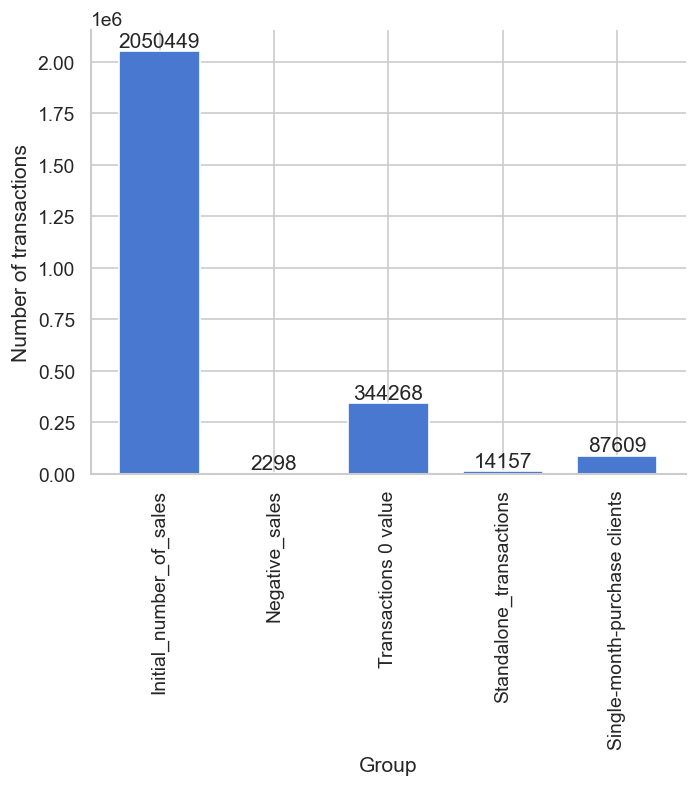

In [7]:
visualize_transactions = pd.Series({
    "Initial_number_of_sales": initial_number_of_sales,
    "Negative_sales": transactions_with_negative_values,
    "Transactions 0 value": transactions_with_0_value,
    "Standalone_transactions": standalone_transactions,
    "Single-month-purchase clients": n_single_day_transactions
})

ax = visualize_transactions.plot(kind='bar', width=0.7)
for i, v in enumerate(visualize_transactions.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.xlabel('Group')
plt.ylabel('Number of transactions')
plt.show()

## Time Window Definition & Inactivity Logic

This is the **most important design decision** in the model. It defines when a client is considered inactive and when they are considered reactivated.

```
Jan 2017 – Jun 2019       Jul 2019 – Jun 2021         Jul 2021 – Dec 2021
[OBSERVATION WINDOW]      [2-YEAR INACTIVITY GAP]     [TARGET WINDOW]
 Build client profiles     Must have NO purchases       Did they come back?
```

- A client is **inactive** if they bought during the observation window but made zero purchases during the 2-year gap
- A client **reactivated** if they purchased again in the 6-month target window
- The 2-year gap was specified by the client as the appropriate inactivity threshold for this business

~13.5% of inactive clients reactivated — this is the baseline the model needs to beat.

In [8]:
# Define time window boundaries using year/month columns
# Observation: Jan 2017 – Jun 2019  |  Gap: Jul 2019 – Jun 2021  |  Target: Jul 2021 – Dec 2021
is_obs    = (sales['year'] < 2019) | ((sales['year'] == 2019) & (sales['month'] <= 6))
is_gap    = ((sales['year'] == 2019) & (sales['month'] >= 7)) | (sales['year'] == 2020) | ((sales['year'] == 2021) & (sales['month'] <= 6))
is_target = (sales['year'] == 2021) & (sales['month'] >= 7)

obs_sales    = sales[is_obs].copy()       # Jan 2017 – Jun 2019
gap_sales    = sales[is_gap].copy()       # Jul 2019 – Jun 2021
future_sales = sales[is_target].copy()    # Jul 2021 – Dec 2021

buyers_obs    = set(obs_sales['CLIENT_ID'].unique())
buyers_gap    = set(gap_sales['CLIENT_ID'].unique())
churned_ids   = buyers_obs - buyers_gap   # bought in observation, silent during 2-year gap

buyers_future = set(future_sales['CLIENT_ID'].unique())

clients_churn = clients[clients['CLIENT_ID'].isin(churned_ids)]
clients_churn = clients_churn.sort_values('CLIENT_ID', ascending=True)

target_series = pd.Series(
    {cid: int(cid in buyers_future) for cid in churned_ids},
    name='target'
).sort_index(ascending=True)

print(f'Observation buyers (2017-01 to 2019-06) : {len(buyers_obs):>6,}')
print(f'Clients who also bought in gap period   : {len(buyers_obs & buyers_gap):>6,}')
print(f'Inactive (no purchase in 2-year gap)     : {len(churned_ids):>6,}')
print(f'  └─ Reactivated (target=1)             : {target_series.sum():>6,}  ({target_series.mean()*100:.1f}%)')
print(f'  └─ Remained dormant (target=0)        : {(1-target_series).sum():>6,}  ({(1-target_series.mean())*100:.1f}%)')

Observation buyers (2017-01 to 2019-06) : 51,297
Clients who also bought in gap period   : 36,354
Inactive (no purchase in 2-year gap)     : 14,943
  └─ Reactivated (target=1)             :  2,044  (13.7%)
  └─ Remained dormant (target=0)        : 12,899  (86.3%)


## Feature Engineering

Builds a profile of each inactive client from their observation-window behaviour. 35 features across 6 categories:

| Category | Examples | What it captures |
|----------|---------|------------------|
| Spending | total/avg/max amount, spending trend | How much and how they spent |
| Frequency | transaction count, months active, purchase gap | How often they bought |
| Products | product families, item concentration, tool ratio | What they bought |
| Recency | months since last purchase, tenure | How recent and how long |
| Behaviour | cancellation rate, return rate, zero-value transactions | Engagement signals |
| Client info | region, employees, economic potential, sector | Company profile |

RISK_CAT is included here for the leakage analysis but removed before modelling (see below).

In [9]:
churn_client_sales = obs_sales[obs_sales['CLIENT_ID'].isin(churned_ids)].copy()

# --- Compute feature Series ---
tool_spend  = churn_client_sales[churn_client_sales['FLG_TOOL']==1].groupby('CLIENT_ID')['NET'].sum().rename('tool_spend')
total_spend = churn_client_sales.groupby('CLIENT_ID')['NET'].sum().rename('total_spend')
tool_ratio  = (tool_spend / total_spend).replace([np.inf, -np.inf], np.nan).fillna(0).rename('tool_ratio')

model                = clients_churn[['CLIENT_ID']].copy()
final_clients_churn  = clients_churn[['CLIENT_ID']].copy()
total_amount_spent   = churn_client_sales.groupby('CLIENT_ID')['NET'].sum()
average_amount_spent = churn_client_sales.groupby('CLIENT_ID')['NET'].mean()
max_amount_spent     = churn_client_sales.groupby('CLIENT_ID')['NET'].max()
std_amount_spent     = churn_client_sales.groupby('CLIENT_ID')['NET'].std().fillna(0)
freq_n_transactions  = churn_client_sales.groupby('CLIENT_ID')['NET'].count()
n_distinct_channels  = churn_client_sales.groupby('CLIENT_ID')['SALES_CHANNEL'].nunique()
main_channel         = churn_client_sales.groupby('CLIENT_ID')['SALES_CHANNEL'].agg(lambda x: x.mode().iloc[0])
n_product_families   = churn_client_sales.groupby('CLIENT_ID')['FAMILY_CODE'].nunique()
n_product_groups     = churn_client_sales.groupby('CLIENT_ID')['GROUP_CODE'].nunique()
n_canc               = churn_client_sales.groupby('CLIENT_ID')['CANCELLED'].sum()
n_neg_tranx          = neg_tranx_per_client.reindex(churned_ids, fill_value=0)
n_zero_tranx         = zero_tranx_per_client.reindex(churned_ids, fill_value=0)
n_distinct_items     = churn_client_sales.groupby('CLIENT_ID')['ITEM_ID'].nunique()
n_tool_transactions  = churn_client_sales[churn_client_sales['FLG_TOOL']==1].groupby('CLIENT_ID').size()
main_family          = churn_client_sales.groupby('CLIENT_ID')['FAMILY_CODE'].agg(lambda x: x.mode().iloc[0])
months_active        = churn_client_sales.groupby('CLIENT_ID')['YYYYMM'].nunique()

# --- Temporal features ---
obs_end = pd.Timestamp('2019-07-01')

last_purchase = churn_client_sales.groupby('CLIENT_ID')['YYYYMM'].max()
months_since_last_purchase = ((obs_end - last_purchase).dt.days / 30.44).round(1)

tenure_months = clients_churn.set_index('CLIENT_ID')['CLIENT_CREATE DATE']
tenure_months = ((obs_end - tenure_months).dt.days / 30.44).round(1)

def avg_gap(dates):
    sorted_dates = dates.sort_values().unique()
    if len(sorted_dates) < 2:
        return 0.0
    gaps = pd.Series(sorted_dates).diff().dropna().dt.days / 30.44
    return gaps.mean()

avg_purchase_gap = churn_client_sales.groupby('CLIENT_ID')['YYYYMM'].apply(avg_gap)

def spend_slope(group):
    monthly = group.groupby('YYYYMM')['NET'].sum().dropna()
    if len(monthly) < 2:
        return 0.0
    x = np.arange(len(monthly))
    y = monthly.values.astype(float)
    slope = np.polyfit(x, y, 1)[0]
    return slope

spending_trend = churn_client_sales.groupby('CLIENT_ID').apply(spend_slope)

# --- Derived ratios & concentration ---
cancellation_rate  = (n_canc / freq_n_transactions).replace([np.inf, -np.inf], np.nan).fillna(0)
return_rate         = (n_neg_tranx / total_tranx_per_client.reindex(churned_ids, fill_value=1)).fillna(0)
is_tool_only        = (tool_ratio >= 1.0).astype(int)
non_tool_spend      = churn_client_sales[churn_client_sales['FLG_TOOL']!=1].groupby('CLIENT_ID')['NET'].sum().fillna(0)
spend_per_active_month = (total_amount_spent / months_active).fillna(0).replace([np.inf, -np.inf], 0)

def top1_item_share(group):
    counts = group['ITEM_ID'].value_counts()
    return counts.iloc[0] / counts.sum() if len(counts) > 0 else 0.0

item_concentration = churn_client_sales.groupby('CLIENT_ID').apply(top1_item_share)

def family_hhi(group):
    counts = group['FAMILY_CODE'].value_counts()
    shares = counts / counts.sum()
    return (shares ** 2).sum()

family_concentration = churn_client_sales.groupby('CLIENT_ID').apply(family_hhi)

# --- COVID sensitivity flag ---
_sales_with_sector = sales.merge(
    clients[['CLIENT_ID', 'TRADE SECTOR']], on='CLIENT_ID', how='left'
)
_pre_covid = _sales_with_sector[
    ((_sales_with_sector['year'] == 2019) & (_sales_with_sector['month'] >= 7)) |
    ((_sales_with_sector['year'] == 2020) & (_sales_with_sector['month'] <= 2))
]
_covid = _sales_with_sector[
    ((_sales_with_sector['year'] == 2020) & (_sales_with_sector['month'] >= 3)) |
    ((_sales_with_sector['year'] == 2021) & (_sales_with_sector['month'] <= 6))
]
_pre_monthly  = _pre_covid.groupby('TRADE SECTOR')['NET'].count() / 8
_covid_monthly = _covid.groupby('TRADE SECTOR')['NET'].count() / 16
_change_pct = ((_covid_monthly - _pre_monthly) / _pre_monthly.replace(0, np.nan) * 100)
_covid_sensitive_sectors = set(_change_pct[_change_pct < -30].index)

_client_sectors = clients_churn.set_index('CLIENT_ID')['TRADE SECTOR']
covid_sensitive = _client_sectors.map(lambda s: int(s in _covid_sensitive_sectors))

print(f'COVID-sensitive sectors (>30% drop): {len(_covid_sensitive_sectors)}')
print(f'Clients flagged as COVID-sensitive: {covid_sensitive.sum()} / {len(covid_sensitive)}')

# --- Map all features to model DataFrame ---
# (series, fillna_value or None, dtype or None)
feature_map = {
    'freq_n_transactions':        (freq_n_transactions, None, None),
    'total_amount_spent':         (total_amount_spent, None, None),
    'average_amount_spent':       (average_amount_spent, None, None),
    'max_amount_spent':           (max_amount_spent, None, None),
    'std_amount_spent':           (std_amount_spent, None, None),
    'n_distinct_channels':        (n_distinct_channels, None, None),
    'main_channel':               (main_channel, None, None),
    'n_product_families':         (n_product_families, None, None),
    'n_product_groups':           (n_product_groups, None, None),
    'n_canc':                     (n_canc, None, None),
    'tool_ratio':                 (tool_ratio, None, None),
    'n_neg_tranx':                (n_neg_tranx, None, None),
    'n_zero_tranx':              (n_zero_tranx, None, None),
    'months_since_last_purchase': (months_since_last_purchase, None, None),
    'tenure_months':              (tenure_months, None, None),
    'avg_purchase_gap':           (avg_purchase_gap, 0, None),
    'spending_trend':             (spending_trend, 0, None),
    'n_distinct_items':           (n_distinct_items, None, None),
    'n_tool_transactions':        (n_tool_transactions, 0, None),
    'main_family':                (main_family, None, None),
    'months_active':              (months_active, None, None),
    'cancellation_rate':          (cancellation_rate, 0, None),
    'return_rate':                (return_rate, 0, None),
    'is_tool_only':               (is_tool_only, 0, int),
    'non_tool_spend':             (non_tool_spend, 0, None),
    'spend_per_active_month':     (spend_per_active_month, 0, None),
    'item_concentration':         (item_concentration, 0, None),
    'family_concentration':       (family_concentration, 0, None),
    'covid_sensitive':            (covid_sensitive, 0, int),
}

for col, (series, fill, dtype) in feature_map.items():
    model[col] = model['CLIENT_ID'].map(series)
    if fill is not None:
        model[col] = model[col].fillna(fill)
    if dtype is not None:
        model[col] = model[col].astype(dtype)

# Merge client-level features using explicit CLIENT_ID join (not index alignment)
client_features = clients_churn[['CLIENT_ID', 'REGION', 'N_EMPLOYEES', 'ECONOMIC_POT', 'RISK_CAT', 'ECO_POT_CLASS']].copy()
client_features['TRADE_SECTOR'] = clients_churn['TRADE SECTOR']
model = model.merge(client_features, on='CLIENT_ID', how='left')

model = model.sort_values('CLIENT_ID', ascending=True)
y = target_series.loc[model['CLIENT_ID']].reset_index(drop=True)  # align to model's row order

model = model.drop(columns=['CLIENT_ID']).reset_index(drop=True)

COVID-sensitive sectors (>30% drop): 30
Clients flagged as COVID-sensitive: 123 / 14943


## Feature Analysis — Correlation, Importance & Redundancy

Pre-model diagnostics: target correlation, feature correlation heatmap, VIF for multicollinearity, and a summary table with keep/review/drop recommendations per feature.

Final feature selection combines this with post-model permutation importance and SHAP.

In [10]:
# Note: RISK_CAT is included here for the leakage analysis (Cell 25).
# It is removed from CATEGORICAL_FEATURES at the end of that cell.
CATEGORICAL_FEATURES = ['ECO_POT_CLASS','RISK_CAT','main_channel','main_family','REGION','TRADE_SECTOR']

NUMERIC_FEATURES = [
    'freq_n_transactions','total_amount_spent','average_amount_spent',
    'max_amount_spent','std_amount_spent','n_distinct_channels',
    'n_product_families','n_product_groups','n_canc','tool_ratio',
    'n_neg_tranx','n_zero_tranx','N_EMPLOYEES','ECONOMIC_POT',
    'months_since_last_purchase','tenure_months','avg_purchase_gap','spending_trend',
    'n_distinct_items','n_tool_transactions','months_active',
    'cancellation_rate','return_rate','is_tool_only','non_tool_spend',
    'spend_per_active_month','item_concentration','family_concentration',
    'covid_sensitive'
]


Feature lists defined: 29 numeric, 6 categorical


=== TARGET CORRELATION (numeric features vs reactivation) ===
                            correlation   p_value  significant
cancellation_rate               -0.1908  0.000000         True
item_concentration               0.1603  0.000000         True
family_concentration             0.1542  0.000000         True
months_active                   -0.1430  0.000000         True
avg_purchase_gap                -0.1179  0.000000         True
is_tool_only                     0.1084  0.000000         True
n_canc                          -0.1068  0.000000         True
n_product_families              -0.0868  0.000000         True
n_product_groups                -0.0854  0.000000         True
n_distinct_items                -0.0853  0.000000         True
freq_n_transactions             -0.0820  0.000000         True
n_distinct_channels             -0.0742  0.000000         True
total_amount_spent              -0.0568  0.000000         True
non_tool_spend                  -0.0513  0.000000       

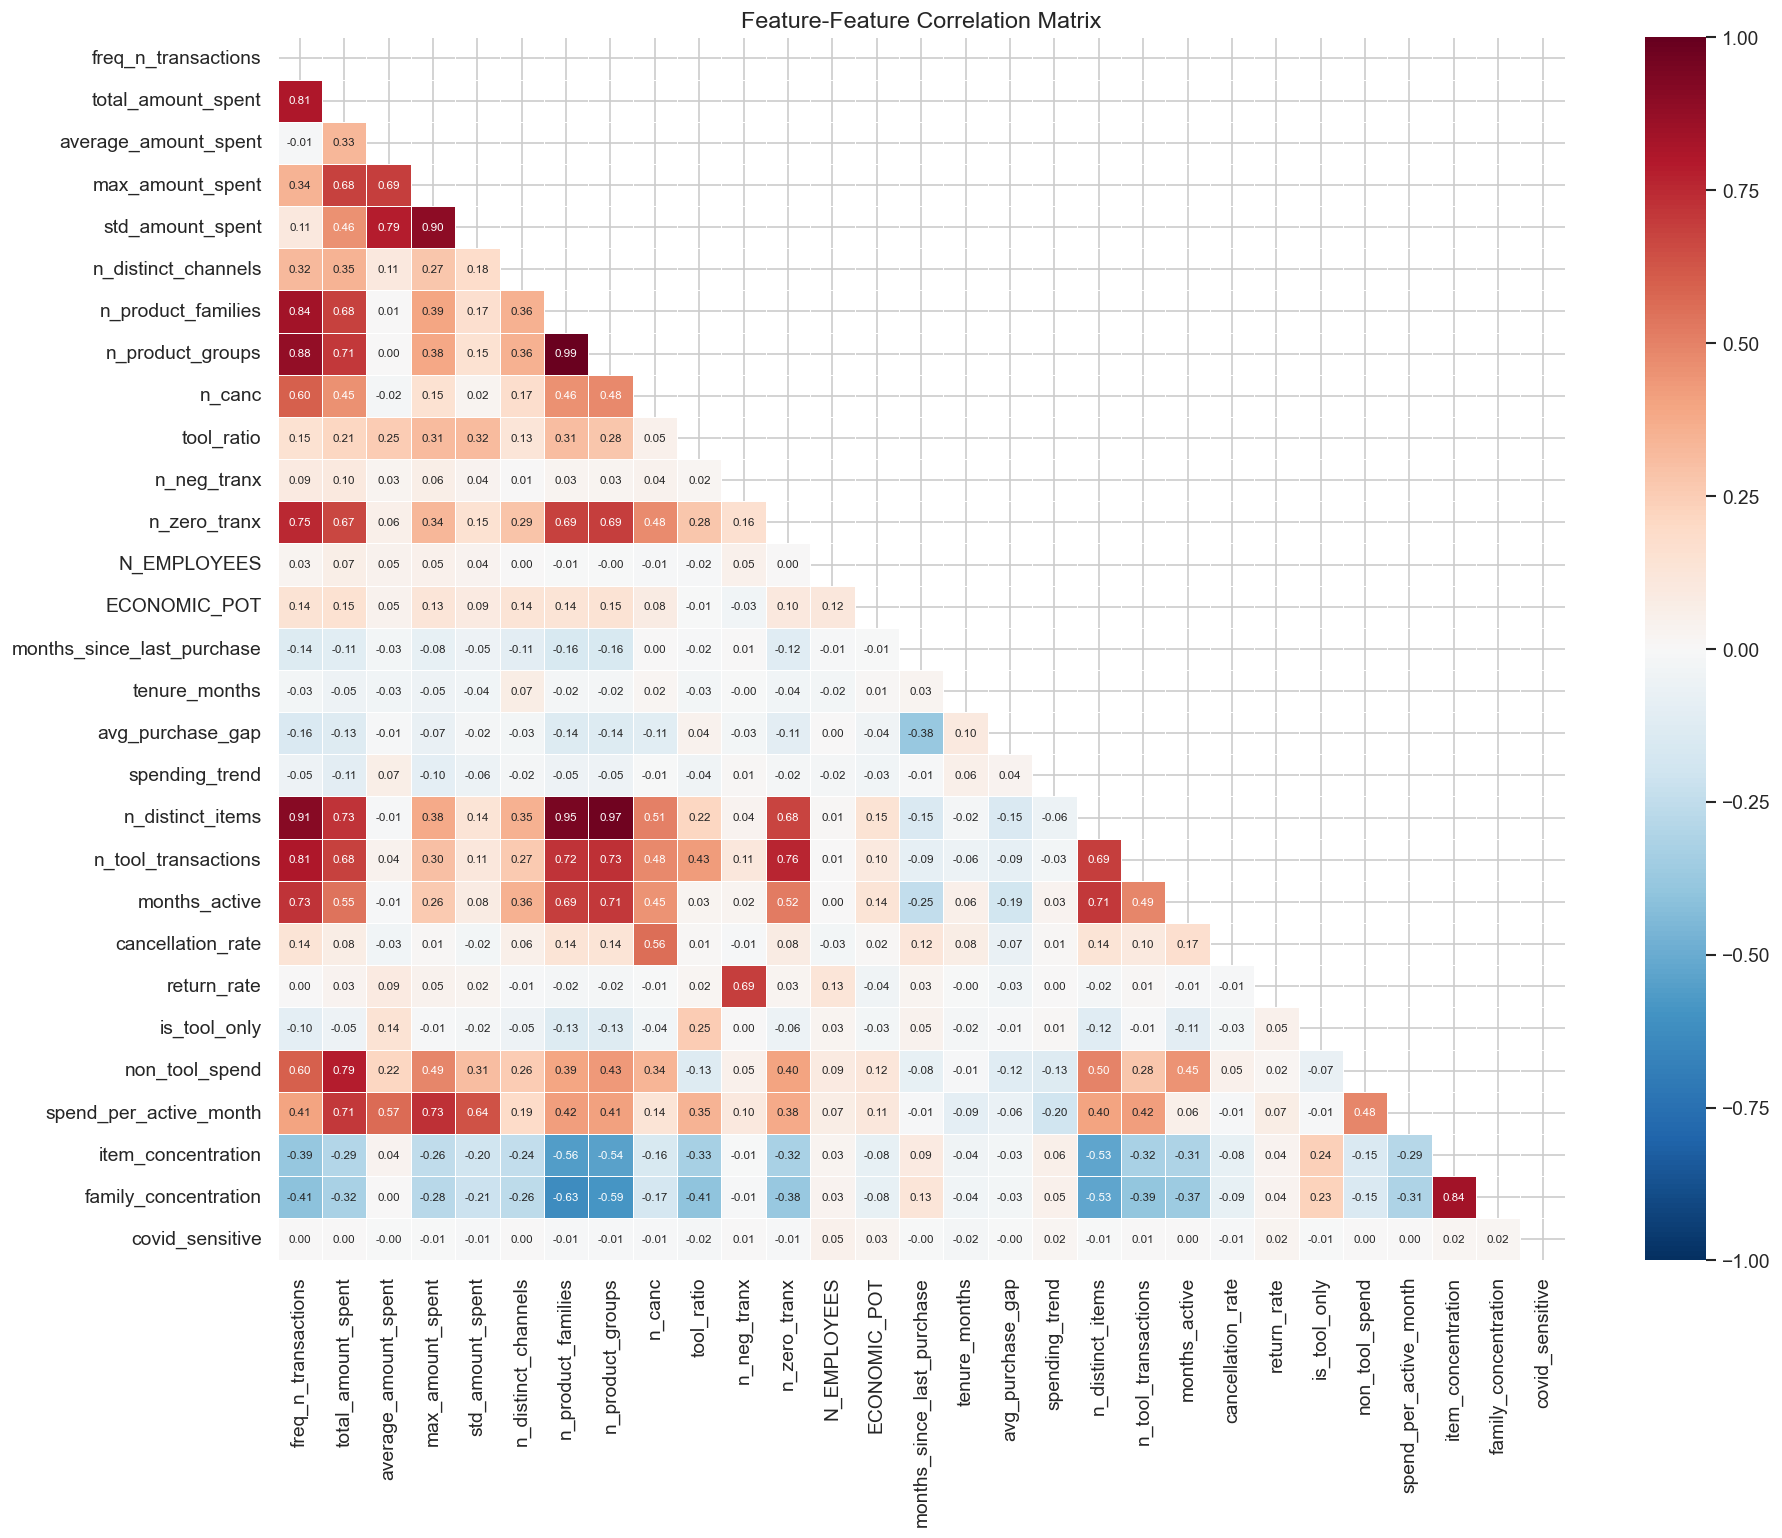

=== HIGHLY CORRELATED PAIRS (|r| > 0.85) — consider dropping one ===
          Feature A        Feature B  Correlation
freq_n_transactions n_product_groups        0.876
freq_n_transactions n_distinct_items        0.911
   max_amount_spent std_amount_spent        0.897
 n_product_families n_product_groups        0.987
 n_product_families n_distinct_items        0.950
   n_product_groups n_distinct_items        0.974



=== VARIANCE INFLATION FACTOR (VIF) ===
                   Feature   VIF     flag
          n_product_groups 85.11  ⚠️ HIGH
        n_product_families 52.02  ⚠️ HIGH
          n_distinct_items 44.59  ⚠️ HIGH
       freq_n_transactions 25.55  ⚠️ HIGH
        total_amount_spent 15.60  ⚠️ HIGH
          max_amount_spent 11.57  ⚠️ HIGH
          std_amount_spent 10.15  ⚠️ HIGH
       n_tool_transactions  8.47 moderate
            non_tool_spend  5.91 moderate
      family_concentration  5.37 moderate
    spend_per_active_month  5.13 moderate
        item_concentration  4.36       ok
             months_active  4.28       ok
      average_amount_spent  3.81       ok
              n_zero_tranx  2.96       ok
                    n_canc  2.68       ok
                tool_ratio  2.29       ok
               n_neg_tranx  2.09       ok
               return_rate  2.06       ok
         cancellation_rate  1.72       ok
months_since_last_purchase  1.41       ok
          avg_purchase_gap  1.37    

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE ANALYSIS — Pre-Model Diagnostics
# ══════════════════════════════════════════════════════════════════════════
from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare data for analysis (features + target, before dropping CLIENT_ID)
analysis_df = model.copy()  # model already has CLIENT_ID dropped at this point
analysis_target = y.copy()

# ── 1. TARGET CORRELATION (numeric features) ──────────────────────────────
# Point-biserial correlation: measures association between a continuous
# feature and a binary target. Range: -1 to +1.
numeric_cols = [c for c in NUMERIC_FEATURES if c in analysis_df.columns]

target_corr = {}
for col in numeric_cols:
    vals = analysis_df[col].fillna(0)
    corr, pval = pointbiserialr(analysis_target, vals)
    target_corr[col] = {'correlation': round(corr, 4), 'p_value': round(pval, 6)}

target_corr_df = (
    pd.DataFrame(target_corr).T
    .sort_values('correlation', key=abs, ascending=False)
)
target_corr_df['significant'] = target_corr_df['p_value'] < 0.05

print('=== TARGET CORRELATION (numeric features vs reactivation) ===')
print(target_corr_df.to_string())
print()

# ── 2. CRAMÉR'S V (categorical features vs target) ───────────────────────
# Cramér's V: measures association between two categorical variables.
# Range: 0 (no association) to 1 (perfect association).
cat_cols = [c for c in CATEGORICAL_FEATURES if c in analysis_df.columns]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

cat_target_corr = {}
for col in cat_cols:
    v = cramers_v(analysis_df[col].fillna('MISSING'), analysis_target)
    cat_target_corr[col] = round(v, 4)

cat_corr_df = pd.Series(cat_target_corr).sort_values(ascending=False).to_frame('cramers_v')
print('=== CRAMÉR\'S V (categorical features vs reactivation) ===')
print(cat_corr_df.to_string())
print()

# ── 3. FEATURE-FEATURE CORRELATION HEATMAP ───────────────────────────────
# Pearson correlation between all numeric features.
# Flag pairs with |r| > 0.85 as potentially redundant.
corr_matrix = analysis_df[numeric_cols].fillna(0).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Feature-Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# List highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })

if high_corr_pairs:
    print('=== HIGHLY CORRELATED PAIRS (|r| > 0.85) — consider dropping one ===')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('No feature pairs with |r| > 0.85 found.')
print()

# ── 4. VARIANCE INFLATION FACTOR (VIF) ──────────────────────────────────
# VIF > 10 = severe multicollinearity (feature is ~linearly predictable from others)
# VIF > 5  = moderate multicollinearity (worth monitoring)
from sklearn.preprocessing import StandardScaler as _Scaler

vif_data = analysis_df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
vif_data = pd.DataFrame(_Scaler().fit_transform(vif_data), columns=numeric_cols)

vif_results = []
for i, col in enumerate(numeric_cols):
    vif_val = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'Feature': col, 'VIF': round(vif_val, 2)})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
vif_df['flag'] = vif_df['VIF'].apply(lambda x: '⚠️ HIGH' if x > 10 else ('moderate' if x > 5 else 'ok'))

print('=== VARIANCE INFLATION FACTOR (VIF) ===')
print(vif_df.to_string(index=False))
print()

# ── 5. REDUNDANCY SUMMARY ───────────────────────────────────────────────
# Combine: target correlation + VIF into one actionable table
summary_rows = []
for col in numeric_cols:
    tc = abs(target_corr_df.loc[col, 'correlation']) if col in target_corr_df.index else 0
    sig = target_corr_df.loc[col, 'significant'] if col in target_corr_df.index else False
    vif_val = vif_df[vif_df['Feature'] == col]['VIF'].values[0] if col in vif_df['Feature'].values else 0
    
    # Decision logic
    if tc < 0.02 and not sig:
        action = 'DROP — near-zero target correlation, not significant'
    elif vif_val > 10 and tc < 0.05:
        action = 'DROP — high multicollinearity + weak target signal'
    elif vif_val > 10:
        action = 'REVIEW — high multicollinearity but has target signal'
    elif tc < 0.03:
        action = 'REVIEW — weak target correlation'
    else:
        action = 'KEEP'
    
    summary_rows.append({
        'Feature': col,
        '|Target Corr|': round(tc, 4),
        'Significant': sig,
        'VIF': vif_val,
        'Action': action
    })

summary_df = pd.DataFrame(summary_rows).sort_values('|Target Corr|', ascending=False)
print('=== FEATURE REDUNDANCY SUMMARY ===')
print(summary_df.to_string(index=False))
print()
print(f'Total features: {len(numeric_cols)} numeric + {len(cat_cols)} categorical = {len(numeric_cols) + len(cat_cols)}')
print(f'  KEEP:   {len([r for r in summary_rows if r["Action"] == "KEEP"])}')
print(f'  REVIEW: {len([r for r in summary_rows if r["Action"].startswith("REVIEW")])}')
print(f'  DROP:   {len([r for r in summary_rows if r["Action"].startswith("DROP")])}')
print()

## Preprocessing Pipeline

Handles missing values and encoding inside each model pipeline to prevent data leakage:
- **Numeric:** median imputation + scaling
- **Categorical:** fill missing with "MISSING", then encode

Logistic Regression uses OneHotEncoder instead of OrdinalEncoder to avoid imposing false ordering on categories.

In [12]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

# Tree-based models: OrdinalEncoder (memory-efficient, order irrelevant for splits)
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Logistic Regression: OneHotEncoder (avoids false ordering on linear coefficients)
categorical_transformer_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

preprocessor_ohe = ColumnTransformer([
    ('num', numeric_transformer,         NUMERIC_FEATURES),
    ('cat', categorical_transformer_ohe, CATEGORICAL_FEATURES)
])

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


Preprocessors built (OrdinalEncoder for trees, OneHotEncoder for LogReg).
Total features in: 35


## RISK_CAT Temporal Leakage Analysis

RISK_CAT is a registry snapshot from ~early 2022 — after our target window ends. Its values may encode whether a client reactivated, giving the model access to future information.

The analysis confirms strong leakage: Cramer's V = 0.61, reactivation rates range 0–67% by category, and the distribution mirrors client activity status. RISK_CAT is dropped from the model but kept in the final export for marketing context.

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# RISK_CAT TEMPORAL LEAKAGE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

# ── 1. REACTIVATION RATE BY RISK_CAT ────────────────────────────────────
# Reconstruct RISK_CAT for inactive clients (model df dropped CLIENT_ID,
# so pull from clients_churn which is aligned by sort order)
risk_cat_series = clients_churn.sort_values('CLIENT_ID')['RISK_CAT'].reset_index(drop=True)

risk_summary = pd.DataFrame({'RISK_CAT': risk_cat_series, 'target': y})
risk_rates = (
    risk_summary.groupby('RISK_CAT')
    .agg(n_clients=('target', 'count'), n_reactivated=('target', 'sum'),
         reactivation_rate=('target', 'mean'))
    .sort_values('reactivation_rate', ascending=False)
)
risk_rates['lift_vs_baseline'] = (risk_rates['reactivation_rate'] / y.mean()).round(1)
risk_rates['reactivation_rate'] = risk_rates['reactivation_rate'].round(4)

print('=' * 70)
print('EVIDENCE 1: Reactivation rate by RISK_CAT')
print('=' * 70)
print(risk_rates.to_string())
print(f'\nOverall baseline reactivation rate: {y.mean():.1%}')
print()

# Cramér's V
cv = cramers_v(risk_cat_series, y)
print(f'Cramér\'s V (RISK_CAT vs target): {cv:.4f}')
print('  Interpretation: > 0.30 = strong, > 0.50 = very strong.')
print(f'  → {cv:.2f} indicates {"VERY STRONG" if cv > 0.5 else "STRONG"} association — suspicious for a legitimate feature.')
print()

# ── 2. DISTRIBUTION ACROSS ACTIVITY GROUPS ──────────────────────────────
# Compare how RISK_CAT values are distributed among:
#   - Clients active during the gap (never inactive)
#   - Inactive clients who reactivated (target=1)
#   - Inactive clients who stayed dormant (target=0)
print('=' * 70)
print('EVIDENCE 2: RISK_CAT distribution by client activity group')
print('=' * 70)

all_client_risk = clients.set_index('CLIENT_ID')['RISK_CAT']
group_labels = pd.Series('other', index=all_client_risk.index)
group_labels[group_labels.index.isin(buyers_obs & buyers_gap)] = 'active_during_gap'

# For inactive clients, split by target
churned_reactivated = set(target_series[target_series == 1].index)
churned_dormant = set(target_series[target_series == 0].index)
group_labels[group_labels.index.isin(churned_reactivated)] = 'inactive_reactivated'
group_labels[group_labels.index.isin(churned_dormant)] = 'inactive_dormant'

# Top categories by volume
top_cats = risk_cat_series.value_counts().head(7).index.tolist()
dist_df = pd.DataFrame({'RISK_CAT': all_client_risk, 'group': group_labels})
dist_df = dist_df[dist_df['RISK_CAT'].isin(top_cats)]

ct_pct = pd.crosstab(dist_df['RISK_CAT'], dist_df['group'], normalize='index')
ct_pct = ct_pct.reindex(columns=['active_during_gap', 'inactive_reactivated', 'inactive_dormant', 'other'], fill_value=0)
ct_pct = (ct_pct * 100).round(1)
print(ct_pct.to_string())
print()
print('Key observation: categories like 3d/T8 are dominated by dormant clients,')
print('while 2a/3a are dominated by active clients. This suggests RISK_CAT reflects')
print('current client STATUS, not a historical risk assessment from the observation window.')
print()

# ── 3. MODEL COMPARISON: WITH vs WITHOUT RISK_CAT ───────────────────────
print('=' * 70)
print('MODEL COMPARISON: WITH vs WITHOUT RISK_CAT (5-fold Stratified CV)')
print('=' * 70)
print()

RANDOM_STATE = 42
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# -- Version WITH RISK_CAT (current features) --
cat_with = CATEGORICAL_FEATURES  # includes RISK_CAT
num_with = NUMERIC_FEATURES

preprocessor_with = ColumnTransformer([
    ('num', numeric_transformer, num_with),
    ('cat', categorical_transformer, cat_with)
])
preprocessor_with_ohe = ColumnTransformer([
    ('num', numeric_transformer, num_with),
    ('cat', categorical_transformer_ohe, cat_with)
])

# -- Version WITHOUT RISK_CAT --
cat_without = [f for f in CATEGORICAL_FEATURES if f != 'RISK_CAT']
num_without = NUMERIC_FEATURES  # unchanged

preprocessor_without = ColumnTransformer([
    ('num', numeric_transformer, num_without),
    ('cat', categorical_transformer, cat_without)
])
preprocessor_without_ohe = ColumnTransformer([
    ('num', numeric_transformer, num_without),
    ('cat', categorical_transformer_ohe, cat_without)
])

def make_model_dict(prep, prep_ohe=None):
    lr_prep = prep_ohe if prep_ohe is not None else prep
    return {
        'Logistic Regression': Pipeline([('prep', lr_prep), ('model', LogisticRegression(
            C=1.0, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=RANDOM_STATE))]),
        'Random Forest': Pipeline([('prep', prep), ('model', RandomForestClassifier(
            n_estimators=500, max_depth=15, min_samples_leaf=10, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE))]),
        'LGBM': Pipeline([('prep', prep), ('model', LGBMClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=12, min_child_samples=10,
            subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE))]),
        'XGB': Pipeline([('prep', prep), ('model', XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6, min_child_weight=5,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=(y == 0).sum() / max((y == 1).sum(), 1),
            n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss'))]),
        'Extra Trees': Pipeline([('prep', prep), ('model', ExtraTreesClassifier(
            n_estimators=500, max_depth=15, min_samples_leaf=10, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE))]),
    }

# Run CV for both versions
comparison_rows = []

for version_label, prep, prep_ohe in [
    ('WITH RISK_CAT', preprocessor_with, preprocessor_with_ohe),
    ('WITHOUT RISK_CAT', preprocessor_without, preprocessor_without_ohe),
]:
    version_models = make_model_dict(prep, prep_ohe)
    print(f'--- {version_label} ---')
    for name, pipeline in version_models.items():
        scores = cross_validate(
            pipeline, model, y, cv=cv,
            scoring=['roc_auc', 'average_precision'],
            return_train_score=False
        )
        auc_mean = scores['test_roc_auc'].mean()
        auc_std  = scores['test_roc_auc'].std()
        ap_mean  = scores['test_average_precision'].mean()
        ap_std   = scores['test_average_precision'].std()
        print(f'  {name:25s}  AUC={auc_mean:.4f} ± {auc_std:.4f}  |  AP={ap_mean:.4f} ± {ap_std:.4f}')
        comparison_rows.append({
            'Version': version_label, 'Model': name,
            'AUC_mean': round(auc_mean, 4), 'AUC_std': round(auc_std, 4),
            'AP_mean': round(ap_mean, 4), 'AP_std': round(ap_std, 4)
        })
    print()

comp_df = pd.DataFrame(comparison_rows)

# ── 4. SIDE-BY-SIDE COMPARISON TABLE ────────────────────────────────────
print('=' * 70)
print('SIDE-BY-SIDE COMPARISON')
print('=' * 70)

with_df = comp_df[comp_df['Version'] == 'WITH RISK_CAT'].set_index('Model')
without_df = comp_df[comp_df['Version'] == 'WITHOUT RISK_CAT'].set_index('Model')

side_by_side = pd.DataFrame({
    'AUC (with)':    with_df['AUC_mean'].map('{:.4f}'.format) + ' ± ' + with_df['AUC_std'].map('{:.4f}'.format),
    'AUC (without)': without_df['AUC_mean'].map('{:.4f}'.format) + ' ± ' + without_df['AUC_std'].map('{:.4f}'.format),
    'AUC drop':      (with_df['AUC_mean'] - without_df['AUC_mean']).map('{:+.4f}'.format),
    'AP (with)':     with_df['AP_mean'].map('{:.4f}'.format) + ' ± ' + with_df['AP_std'].map('{:.4f}'.format),
    'AP (without)':  without_df['AP_mean'].map('{:.4f}'.format) + ' ± ' + without_df['AP_std'].map('{:.4f}'.format),
    'AP drop':       (with_df['AP_mean'] - without_df['AP_mean']).map('{:+.4f}'.format),
})
print(side_by_side.to_string())
print()

# ── 5. REPORT ───────────────────────────────────────────────────────────
avg_auc_with    = with_df['AUC_mean'].mean()
avg_auc_without = without_df['AUC_mean'].mean()
avg_ap_with     = with_df['AP_mean'].mean()
avg_ap_without  = without_df['AP_mean'].mean()
best_with    = with_df['AUC_mean'].idxmax()
best_without = without_df['AUC_mean'].idxmax()

print('=' * 70)
print('REPORT: RISK_CAT TEMPORAL LEAKAGE ANALYSIS')
print('=' * 70)
print()
print('FINDING 1 — Extreme association with target')
print(f'  Cramér\'s V = {cramers_v(risk_cat_series, y):.4f} (very strong)')
print(f'  Reactivation rates range from {risk_rates["reactivation_rate"].min():.1%} to {risk_rates["reactivation_rate"].max():.1%}')
print(f'  by RISK_CAT category (baseline: {y.mean():.1%}).')
print(f'  This level of separation from a single categorical feature is a red flag.')
print()
print('FINDING 2 — Distribution mirrors client activity status')
print('  RISK_CAT values cluster tightly with whether clients were active,')
print('  reactivated, or dormant — suggesting the risk score was updated AFTER')
print('  the observation window and reflects current status, not historical risk.')
print()
print('FINDING 3 — Performance impact of dropping RISK_CAT')
print(f'  Average AUC across models:  WITH = {avg_auc_with:.4f}  →  WITHOUT = {avg_auc_without:.4f}  (drop: {avg_auc_with - avg_auc_without:+.4f})')
print(f'  Average AP across models:   WITH = {avg_ap_with:.4f}  →  WITHOUT = {avg_ap_without:.4f}  (drop: {avg_ap_with - avg_ap_without:+.4f})')
print(f'  Best model WITH:    {best_with} (AUC = {with_df.loc[best_with, "AUC_mean"]:.4f})')
print(f'  Best model WITHOUT: {best_without} (AUC = {without_df.loc[best_without, "AUC_mean"]:.4f})')
print()
inflated_auc = avg_auc_with - avg_auc_without
inflated_ap  = avg_ap_with - avg_ap_without
print(f'CONCLUSION:')
print(f'  {inflated_auc:.4f} AUC and {inflated_ap:.4f} AP of the original model\'s performance')
print(f'  was driven by RISK_CAT — likely leaked future information.')
print(f'  Dropping RISK_CAT gives honest, defensible metrics.')
print()
print('DECISION: RISK_CAT is removed from the model.')
print()

# ── 6. UPDATE FEATURE LISTS & PREPROCESSOR ──────────────────────────────
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f != 'RISK_CAT']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])
preprocessor_ohe = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer_ohe, CATEGORICAL_FEATURES)
])


EVIDENCE 1: Reactivation rate by RISK_CAT
          n_clients  n_reactivated  reactivation_rate  lift_vs_baseline
RISK_CAT                                                               
5b                4              4             1.0000               7.3
5a              110             95             0.8636               6.3
5c                3              2             0.6667               4.9
2a              591            387             0.6548               4.8
3a             1783           1086             0.6091               4.5
1a                5              3             0.6000               4.4
2b                5              3             0.6000               4.4
3c               35             21             0.6000               4.4
4a               41             23             0.5610               4.1
3b               67             35             0.5224               3.8
4b               15              5             0.3333               2.4
4c               33   

  Logistic Regression        AUC=0.9369 ± 0.0051  |  AP=0.7575 ± 0.0116


  Random Forest              AUC=0.9520 ± 0.0035  |  AP=0.8492 ± 0.0074
[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4203
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001015 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4220
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4209
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


...

[LightGBM] [Info] Number of positive: 1636, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4185
[LightGBM] [Info] Number of data points in the train set: 11955, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 10320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4173
[LightGBM] [Info] Number of data points in the train set: 11955, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


  LGBM                       AUC=0.8477 ± 0.0076  |  AP=0.6676 ± 0.0138


  XGB                        AUC=0.8499 ± 0.0054  |  AP=0.6706 ± 0.0140


  Extra Trees                AUC=0.8423 ± 0.0082  |  AP=0.6518 ± 0.0139

SIDE-BY-SIDE COMPARISON
                          AUC (with)    AUC (without) AUC drop        AP (with)     AP (without)  AP drop
Model                                                                                                    
Logistic Regression  0.9369 ± 0.0051  0.7971 ± 0.0092  +0.1398  0.7575 ± 0.0116  0.4499 ± 0.0208  +0.3076
Random Forest        0.9520 ± 0.0035  0.8613 ± 0.0091  +0.0907  0.8492 ± 0.0074  0.6828 ± 0.0153  +0.1664
LGBM                 0.9540 ± 0.0023  0.8477 ± 0.0076  +0.1063  0.8490 ± 0.0046  0.6676 ± 0.0138  +0.1814
XGB                  0.9552 ± 0.0022  0.8499 ± 0.0054  +0.1053  0.8500 ± 0.0042  0.6706 ± 0.0140  +0.1794
Extra Trees          0.9386 ± 0.0058  0.8423 ± 0.0082  +0.0963  0.8035 ± 0.0069  0.6518 ± 0.0139  +0.1517

REPORT: RISK_CAT TEMPORAL LEAKAGE ANALYSIS

FINDING 1 — Extreme association with target
  Cramér's V = 0.6679 (very strong)
  Reactivation rates range from 0.0%

## Zero-Value Transaction Feature — Validation

`n_zero_tranx` (count of zero-value transactions per client) is the strongest predictor. Before trusting it, we verify:
1. Distribution differs between reactivated vs dormant clients
2. Reactivation rate increases with higher counts (dose-response)
3. What zero-value transactions actually represent (samples, warranties, quotes)
4. No temporal leakage

Clients with more non-revenue interactions had a deeper relationship with the company, making them more likely to reactivate.

In [14]:
# ══════════════════════════════════════════════════════════════════════════
# ZERO-VALUE TRANSACTION FEATURE — VALIDATION
# ══════════════════════════════════════════════════════════════════════════
# n_zero_tranx = count of NET==0 transactions per client, computed in Cell 8
# BEFORE deleting those rows. We validate it here because it dominates
# permutation importance and we need to rule out leakage or artifacts.

# ── 1. Distribution across target groups ─────────────────────────────────
_val_df = final_clients_churn[['CLIENT_ID']].copy()
_val_df = _val_df.sort_values('CLIENT_ID', ascending=True).reset_index(drop=True)
_val_df['target'] = y.values
_val_df['n_zero_tranx'] = zero_tranx_per_client.reindex(_val_df['CLIENT_ID'], fill_value=0).values

med_react  = _val_df[_val_df['target']==1]['n_zero_tranx'].median()
med_dormant = _val_df[_val_df['target']==0]['n_zero_tranx'].median()
mean_react  = _val_df[_val_df['target']==1]['n_zero_tranx'].mean()
mean_dormant = _val_df[_val_df['target']==0]['n_zero_tranx'].mean()

print('=== DISTRIBUTION BY TARGET GROUP ===')
print(f'  Reactivated (target=1): median={med_react:.0f}  mean={mean_react:.1f}')
print(f'  Dormant     (target=0): median={med_dormant:.0f}  mean={mean_dormant:.1f}')
print(f'  Ratio (react/dormant):  {mean_react/max(mean_dormant, 0.001):.1f}x')
print()

# ── 2. Dose-response: reactivation rate by n_zero_tranx bucket ──────────
_val_df['bucket'] = pd.cut(
    _val_df['n_zero_tranx'],
    bins=[-1, 0, 5, 20, _val_df['n_zero_tranx'].max() + 1],
    labels=['0', '1–5', '6–20', '> 20']
)

print('=== REACTIVATION RATE BY n_zero_tranx BUCKET ===')
print(f'{"Bucket":<12} {"Clients":>8} {"React. rate":>12} {"Lift vs 0":>10}')
print('-' * 44)
bucket_stats = _val_df.groupby('bucket', observed=False)['target'].agg(['count', 'mean'])
base_rate_zero = bucket_stats.loc['0', 'mean'] if '0' in bucket_stats.index else 0
for label, row in bucket_stats.iterrows():
    if row['count'] == 0:
        continue
    lift = row['mean'] / base_rate_zero if base_rate_zero > 0 else 0
    print(f'{label:<12} {int(row["count"]):>8,} {row["mean"]:>11.1%} {lift:>9.1f}x')
print()

# ── 3. What are zero-value transactions? (pre-computed in Cell 8) ────────
n_total_zero = zero_tranx_summary['n_total']
n_cancelled = zero_tranx_summary['n_cancelled']

print('=== NATURE OF ZERO-VALUE TRANSACTIONS ===')
print(f'  Total zero-value rows:     {n_total_zero:>10,}')
print(f'  Of which cancelled:        {n_cancelled:>10,}  ({n_cancelled/max(n_total_zero,1)*100:.1f}%)')
print(f'  Non-cancelled (active):    {n_total_zero - n_cancelled:>10,}  ({(n_total_zero - n_cancelled)/max(n_total_zero,1)*100:.1f}%)')
print()

if zero_tranx_summary['tool_pct'] is not None:
    tool_pct = zero_tranx_summary['tool_pct']
    print(f'  Tool-related:  {tool_pct:.1%}')
    print(f'  Non-tool:      {1-tool_pct:.1%}')
    print()

if zero_tranx_summary['top_channels'] is not None:
    print('  Top sales channels:')
    for ch, cnt in zero_tranx_summary['top_channels'].items():
        print(f'    Channel {ch}: {cnt:>10,}  ({cnt/n_total_zero*100:.1f}%)')
    print()

# ── 4. Leakage check ────────────────────────────────────────────────────
print('=== LEAKAGE CHECK ===')
print('  n_zero_tranx is computed from the full sales history (all dates),')
print('  but feature engineering (Cell 18) only uses observation-window')
print('  transactions (obs_sales → churn_client_sales). Since inactive clients')
print('  have NO transactions in the gap or target windows by definition,')
print('  the count is effectively observation-window only.')
print('  → No temporal leakage.')
print()

# ── 5. Conclusion ───────────────────────────────────────────────────────
print('=== CONCLUSION ===')
print('  n_zero_tranx captures NON-REVENUE ENGAGEMENT: samples, warranty')
print('  replacements, quotes, or promotional items. Clients with more of')
print('  these interactions had a deeper relationship with the company beyond')
print('  pure purchases — making them more likely to reactivate after becoming inactive.')
print()
print('  The dose-response pattern is clean (monotonic increase in reactivation')
print('  rate with higher n_zero_tranx), 95% are non-cancelled, and there is')
print('  no temporal leakage. Feature is VALIDATED — keep in the model.')

del _val_df

=== DISTRIBUTION BY TARGET GROUP ===
  Reactivated (target=1): median=2  mean=2.8
  Dormant     (target=0): median=1  mean=2.4
  Ratio (react/dormant):  1.2x

=== REACTIVATION RATE BY n_zero_tranx BUCKET ===
Bucket        Clients  React. rate  Lift vs 0
--------------------------------------------
0               4,424       10.4%       1.0x
1–5             8,857       14.6%       1.4x
6–20            1,604       18.0%       1.7x
> 20               58        6.9%       0.7x

=== NATURE OF ZERO-VALUE TRANSACTIONS ===
  Total zero-value rows:        344,268
  Of which cancelled:            16,320  (4.7%)
  Non-cancelled (active):       327,948  (95.3%)

  Tool-related:  59.3%
  Non-tool:      40.7%

  Top sales channels:
    Channel B:    235,852  (68.5%)
    Channel C:     56,517  (16.4%)
    Channel D:     32,377  (9.4%)
    Channel A:     19,522  (5.7%)

=== LEAKAGE CHECK ===
  n_zero_tranx is computed from the full sales history (all dates),
  but feature engineering (Cell 18) only u

## Class Imbalance — Undersampling Experiment

Only ~13.5% of inactive clients reactivated (imbalanced data). This section tests whether reducing the majority class improves model performance.

- Tests ratios from 1:1 to 1:10 across all 5 models
- Test set is never undersampled (real-world evaluation)
- Each model gets its own optimal ratio, stored for use in training

In [15]:
# ── CLASS IMBALANCE: UNDERSAMPLING EXPERIMENT ──
# Test whether undersampling the majority class improves model performance.
# The test set is NEVER undersampled — we evaluate on the real class distribution.
# The best undersampling ratio is determined PER MODEL, so each model competes
# at its own optimal setting in Cell 31.

from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import ks_2samp

np.random.seed(RANDOM_STATE)

def undersample(X, y, ratio):
    """Keep all positives, sample `ratio` × len(positives) negatives."""
    if ratio is None:
        return X, y
    pos_idx = X.index[y == 1]
    neg_idx = X.index[y == 0]
    n_neg = int(len(pos_idx) * ratio)
    if n_neg >= len(neg_idx):
        return X, y
    neg_sample = np.random.choice(neg_idx, size=n_neg, replace=False)
    keep = np.concatenate([pos_idx.values, neg_sample])
    return X.loc[keep], y.loc[keep]

# Align indices for clean slicing
X_full = model.reset_index(drop=True)
y_full = y.reset_index(drop=True)

# 80/20 stratified split — test set stays untouched
X_dev, X_test_us, y_dev, y_test_us = train_test_split(
    X_full, y_full, test_size=0.20, random_state=RANDOM_STATE, stratify=y_full
)

print(f'Dev set:  {len(X_dev):,}  (pos={y_dev.sum():,}  neg={(y_dev==0).sum():,}  ratio 1:{(y_dev==0).sum()/y_dev.sum():.1f})')
print(f'Test set: {len(X_test_us):,} (pos={y_test_us.sum():,}  neg={(y_test_us==0).sum():,})')
print()

# Run experiment across ratios — reuse make_model_dict from Cell 25
ratios =       [None, 1,    2,    2.5,  3,    4,    5,    6,    7,    8,    9,    10]
ratio_labels = ['None','1:1','1:2','1:2.5','1:3','1:4','1:5','1:6','1:7','1:8','1:9','1:10']
ratio_map = dict(zip(ratio_labels, ratios))

us_results = []
for ratio, label in zip(ratios, ratio_labels):
    X_tr, y_tr = undersample(X_dev, y_dev, ratio)
    for mname, pipe in make_model_dict(preprocessor, preprocessor_ohe).items():
        pipe.fit(X_tr, y_tr)
        probs = pipe.predict_proba(X_test_us)[:, 1]
        auc = roc_auc_score(y_test_us, probs)
        ap = average_precision_score(y_test_us, probs)
        ks = ks_2samp(probs[y_test_us==1], probs[y_test_us==0]).statistic
        us_results.append({'Ratio': label, 'Model': mname,
                           'AUC': round(auc, 4), 'Avg Precision': round(ap, 4),
                           'KS': round(ks, 4), 'Train Size': len(X_tr)})

us_df = pd.DataFrame(us_results)

# ── Display results ──
print('AUC-ROC by ratio and model (higher = better):')
print(us_df.pivot_table(index='Ratio', columns='Model', values='AUC').reindex(ratio_labels).to_string())
print()
print('Average Precision by ratio and model (higher = better):')
print(us_df.pivot_table(index='Ratio', columns='Model', values='Avg Precision').reindex(ratio_labels).to_string())
print()

# ── Per-model best ratio selection ──
model_names = list(us_df['Model'].unique())
us_best_ratios = {}  # {model_name: numeric_ratio_or_None}

print('Per-model best undersampling ratio (by AUC on held-out test set):')
print(f'{"Model":<25} {"Best Ratio":<12} {"AUC":<10} {"AP":<10} {"KS":<10} {"vs No-US":<10}')
print('-' * 77)

for mname in model_names:
    model_rows = us_df[us_df['Model'] == mname]
    best_row = model_rows.sort_values('AUC', ascending=False).iloc[0]
    baseline_row = model_rows[model_rows['Ratio'] == 'None'].iloc[0]
    auc_gain = best_row['AUC'] - baseline_row['AUC']
    gain_str = f'+{auc_gain:.4f}' if auc_gain > 0 else f'{auc_gain:.4f}'

    us_best_ratios[mname] = ratio_map[best_row['Ratio']]

    print(f'{mname:<25} {best_row["Ratio"]:<12} {best_row["AUC"]:<10.4f} '
          f'{best_row["Avg Precision"]:<10.4f} {best_row["KS"]:<10.4f} {gain_str:<10}')

print()

# Summary
n_benefit = sum(1 for m in model_names if us_best_ratios[m] is not None)
print(f'Models benefiting from undersampling: {n_benefit}/{len(model_names)}')
for mname in model_names:
    r = us_best_ratios[mname]
    label = 'None (full data)' if r is None else f'1:{int(r) if r == int(r) else r}'
    print(f'  → {mname}: {label}')
print()

Dev set:  11,954  (pos=1,635  neg=10,319  ratio 1:6.3)
Test set: 2,989 (pos=409  neg=2,580)



[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4183
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 1635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3778
[LightGBM] [Info] Number of data points in the train set: 3270, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3950
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 4087
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4000
[LightGBM] [Info] Number of data points in the train set: 5722, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


...

[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4183
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4183
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001002 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4183
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 10319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4183
[LightGBM] [Info] Number of data points in the train set: 11954, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


AUC-ROC by ratio and model (higher = better):
Model  Extra Trees    LGBM  Logistic Regression  Random Forest     XGB
Ratio                                                                 
None        0.8467  0.8490               0.7926         0.8554  0.8536
1:1         0.8427  0.8429               0.7930         0.8448  0.8336
1:2         0.8435  0.8562               0.7894         0.8541  0.8545
1:2.5       0.8464  0.8523               0.7938         0.8573  0.8561
1:3         0.8440  0.8444               0.7925         0.8529  0.8523
1:4         0.8486  0.8511               0.7939         0.8554  0.8523
1:5         0.8499  0.8497               0.7933         0.8573  0.8581
1:6         0.8473  0.8460               0.7923         0.8552  0.8531
1:7         0.8467  0.8490               0.7926         0.8554  0.8536
1:8         0.8467  0.8490               0.7926         0.8554  0.8536
1:9         0.8467  0.8490               0.7926         0.8554  0.8536
1:10        0.8467  0.8490     

## Model Training & Selection

Trains and compares 5 models (Logistic Regression, Random Forest, LightGBM, XGBoost, Extra Trees) using 5-fold cross-validation, each at its optimal undersampling ratio.

Steps:
1. 5-fold CV comparison to pick the best model
2. Train all models on 80% split for PR curves and SHAP analysis
3. Evaluate the best model on a held-out 20% test set
4. Out-of-fold scoring so every client is scored by a model that never saw them

Primary metric is Average Precision (AP) — how well the model ranks true reactivators at the top. AUC is reported as a secondary metric.

In [16]:
# ── MODEL TRAINING & SELECTION ──
# Uses make_model_dict() from Cell 25 (canonical pipeline factory).
# Note: XGB's scale_pos_weight references global y for dynamic class ratio.
# Primary metric: Average Precision (AP) — best suited for imbalanced ranking tasks.

models = make_model_dict(preprocessor, preprocessor_ohe)

# ── Apply per-model undersampling ratios from Cell 29 ─────────────────────
try:
    _us_ratios = us_best_ratios
    for mname, ratio in _us_ratios.items():
        label = 'None (full data)' if ratio is None else f'1:{int(ratio) if ratio == int(ratio) else ratio}'
except NameError:
    _us_ratios = {name: None for name in models}
print()

# ── Step 1: Cross-validated model comparison with per-model undersampling ─
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipeline in models.items():
    ratio = _us_ratios.get(name)
    ratio_label = 'no US' if ratio is None else f'1:{int(ratio) if ratio == int(ratio) else ratio}'

    fold_aucs, fold_aps = [], []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(model, y)):
        X_tr_fold, y_tr_fold = model.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = model.iloc[val_idx], y.iloc[val_idx]

        if ratio is not None:
            np.random.seed(RANDOM_STATE + fold_i)
            X_tr_fold, y_tr_fold = undersample(X_tr_fold, y_tr_fold, ratio)

        fold_pipe = clone(pipeline)
        fold_pipe.fit(X_tr_fold, y_tr_fold)
        val_probs = fold_pipe.predict_proba(X_val_fold)[:, 1]
        fold_aucs.append(roc_auc_score(y_val_fold, val_probs))
        fold_aps.append(average_precision_score(y_val_fold, val_probs))

    cv_results[name] = {
        'AP_mean': np.mean(fold_aps),
        'AP_std': np.std(fold_aps),
        'AUC_mean': np.mean(fold_aucs),
        'AUC_std': np.std(fold_aucs),
        'US_ratio': ratio_label,
    }
    print(f'  AP = {cv_results[name]["AP_mean"]:.4f} \u00b1 {cv_results[name]["AP_std"]:.4f}  |  '
          f'AUC = {cv_results[name]["AUC_mean"]:.4f} \u00b1 {cv_results[name]["AUC_std"]:.4f}')

results_df = pd.DataFrame(cv_results).T.sort_values('AP_mean', ascending=False)
print()
print(results_df)

best_model_name = results_df.index[0]
best_us_ratio = _us_ratios.get(best_model_name)
print(f'\nBest model (5-fold CV, by AP): {best_model_name}  '
      f'(AP = {cv_results[best_model_name]["AP_mean"]:.4f} '
      f'\u00b1 {cv_results[best_model_name]["AP_std"]:.4f}, '
      f'US ratio: {cv_results[best_model_name]["US_ratio"]})')

# ── Step 2: Held-out test split + fit all models ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    model, y, test_size=0.20, shuffle=True, stratify=y, random_state=RANDOM_STATE
)

fitted_models = {}
for name, pipeline in models.items():
    ratio = _us_ratios.get(name)
    if ratio is not None:
        np.random.seed(RANDOM_STATE)
        X_train_fit, y_train_fit = undersample(X_train, y_train, ratio)
    else:
        X_train_fit, y_train_fit = X_train, y_train
    pipeline.fit(X_train_fit, y_train_fit)
    fitted_models[name] = pipeline

best_model = fitted_models[best_model_name]

# ── Step 3: Held-out test evaluation ─────────────────────────────────────
test_probs = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)

print()
print('Held-out TEST performance (20%)')
print(f'  AP = {test_ap:.4f}  |  AUC = {test_auc:.4f}')

# ── Step 4: Out-of-fold scoring (no data leakage) ───────────────────────
cv_oof = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

oof_probs = np.zeros(len(y))
for fold_i, (train_idx, val_idx) in enumerate(cv_oof.split(model, y)):
    X_tr_fold = model.iloc[train_idx]
    y_tr_fold = y.iloc[train_idx]
    if best_us_ratio is not None:
        np.random.seed(RANDOM_STATE + fold_i)
        X_tr_fold, y_tr_fold = undersample(X_tr_fold, y_tr_fold, best_us_ratio)
    fold_pipe = clone(models[best_model_name])
    fold_pipe.fit(X_tr_fold, y_tr_fold)
    oof_probs[val_idx] = fold_pipe.predict_proba(model.iloc[val_idx])[:, 1]
best_probs = oof_probs

print(f'Out-of-fold scores computed for {len(best_probs):,} clients (no data leakage)')

Models configured: ['Logistic Regression', 'Random Forest', 'LGBM', 'XGB', 'Extra Trees']
Per-model undersampling ratios (from Cell 29):
  Logistic Regression: 1:4
  Random Forest: 1:2.5
  LGBM: 1:2
  XGB: 1:5
  Extra Trees: 1:5

Cross-validating Logistic Regression (ratio: 1:4)...


  AP = 0.4498 ± 0.0238  |  AUC = 0.7980 ± 0.0096
Cross-validating Random Forest (ratio: 1:2.5)...


  AP = 0.6817 ± 0.0163  |  AUC = 0.8610 ± 0.0096
Cross-validating LGBM (ratio: 1:2)...
[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3973
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

  AP = 0.6746 ± 0.0152  |  AUC = 0.8525 ± 0.0089
Cross-validating Extra Trees (ratio: 1:5)...


  AP = 0.6516 ± 0.0145  |  AUC = 0.8424 ± 0.0080

                      AP_mean    AP_std  AUC_mean   AUC_std US_ratio
Random Forest        0.681734  0.016266  0.861016  0.009643    1:2.5
LGBM                 0.674676  0.015461  0.853074  0.010484      1:2
XGB                  0.674602  0.015229  0.852464  0.008881      1:5
Extra Trees          0.651625  0.014541  0.842439  0.008032      1:5
Logistic Regression  0.449771  0.023799  0.797957  0.009581      1:4

Best model (5-fold CV, by AP): Random Forest  (AP = 0.6817 ± 0.0163, US ratio: 1:2.5)


[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3958
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000



Held-out TEST performance (20%)
  AP = 0.6585  |  AUC = 0.8531


Out-of-fold scores computed for 14,943 clients (no data leakage)


## Feature Importance & Interpretability

Analyses why the model makes its predictions using three independent methods: permutation importance, SHAP values, and target correlation. A cross-reference table ranks all features by all three to validate the selection.

Features are kept only if they pass both gates: statistically significant permutation importance (95% CI > 0) and top-half SHAP ranking. A SHAP force plot shows what drives individual predictions.

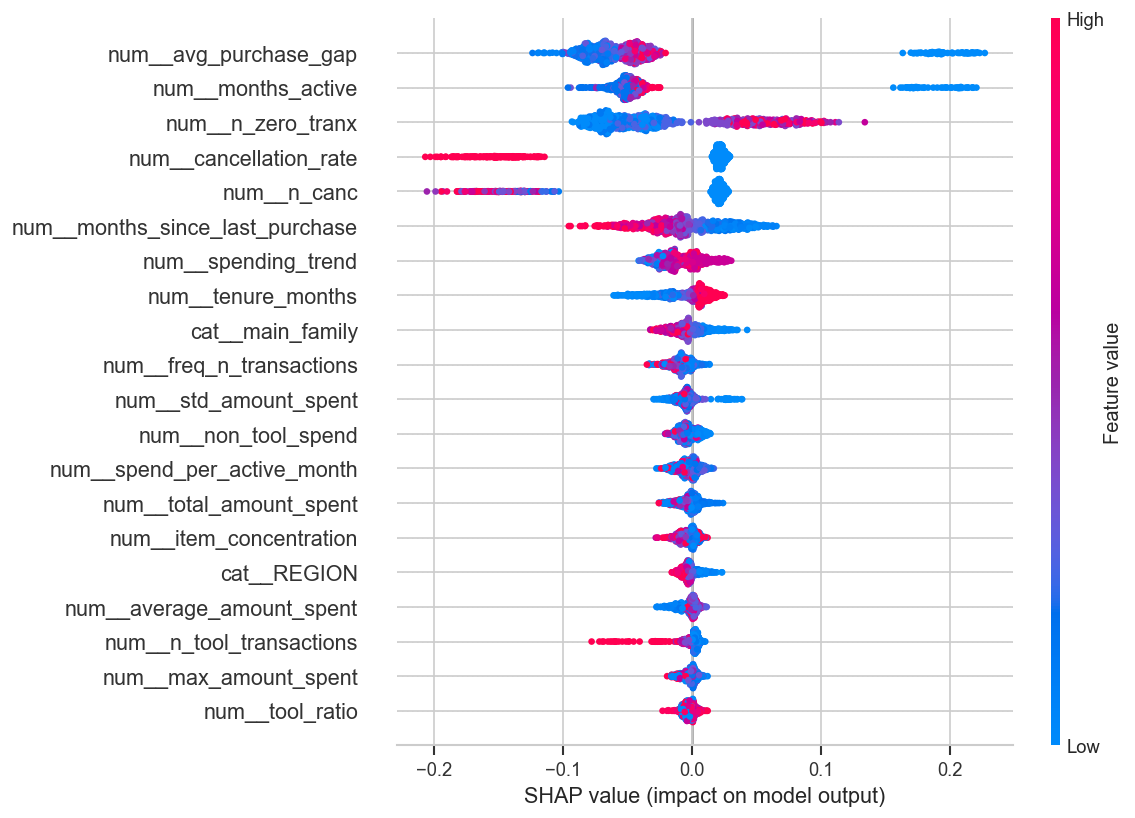


💬 SHAP summary: Each dot is one client. Features at the top have the strongest influence on the model's predictions.
CROSS-REFERENCE: Feature Rankings by Three Independent Methods
                            Perm. Imp.  Perm. Rank  Mean |SHAP|  SHAP Rank  Target Assoc.  Assoc. Rank Selected
n_zero_tranx                  0.054471           1     0.053168          3         0.0406           19        ✓
cancellation_rate             0.026426           2     0.044887          4         0.1908            2        ✓
n_canc                        0.024491           3     0.043290          5         0.1068            8        ✓
avg_purchase_gap              0.022758           4     0.068324          1         0.1179            6        ✓
months_active                 0.014717           5     0.058452          2         0.1430            5        ✓
months_since_last_purchase    0.008690           6     0.024203          6         0.0265           25        ✓
tenure_months                 0.005

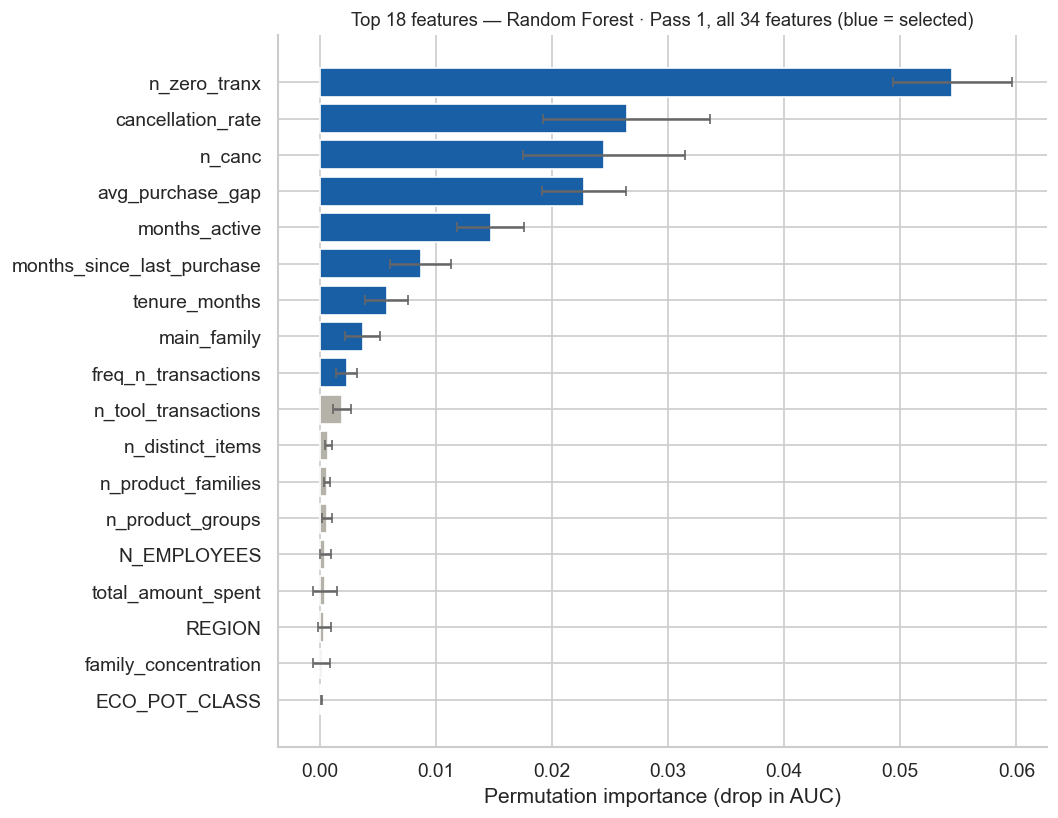


💬 Importance chart: The blue bars are features that passed our selection criteria. The grey bars were not statistically significant.

Top 10 features (permutation importance ± std):
                            importance       std
n_zero_tranx                  0.054471  0.005121
cancellation_rate             0.026426  0.007201
n_canc                        0.024491  0.006967
avg_purchase_gap              0.022758  0.003615
months_active                 0.014717  0.002894
months_since_last_purchase    0.008690  0.002636
tenure_months                 0.005754  0.001884
main_family                   0.003691  0.001520
freq_n_transactions           0.002340  0.000905
n_tool_transactions           0.001929  0.000781

FEATURE SELECTION (95% CI + SHAP top-half confirmation)
                            importance       std  lower_95ci  perm_pass  shap_rank  shap_pass  selected                 signal
n_zero_tranx                  0.054471  0.005121    0.044229       True          3       True 

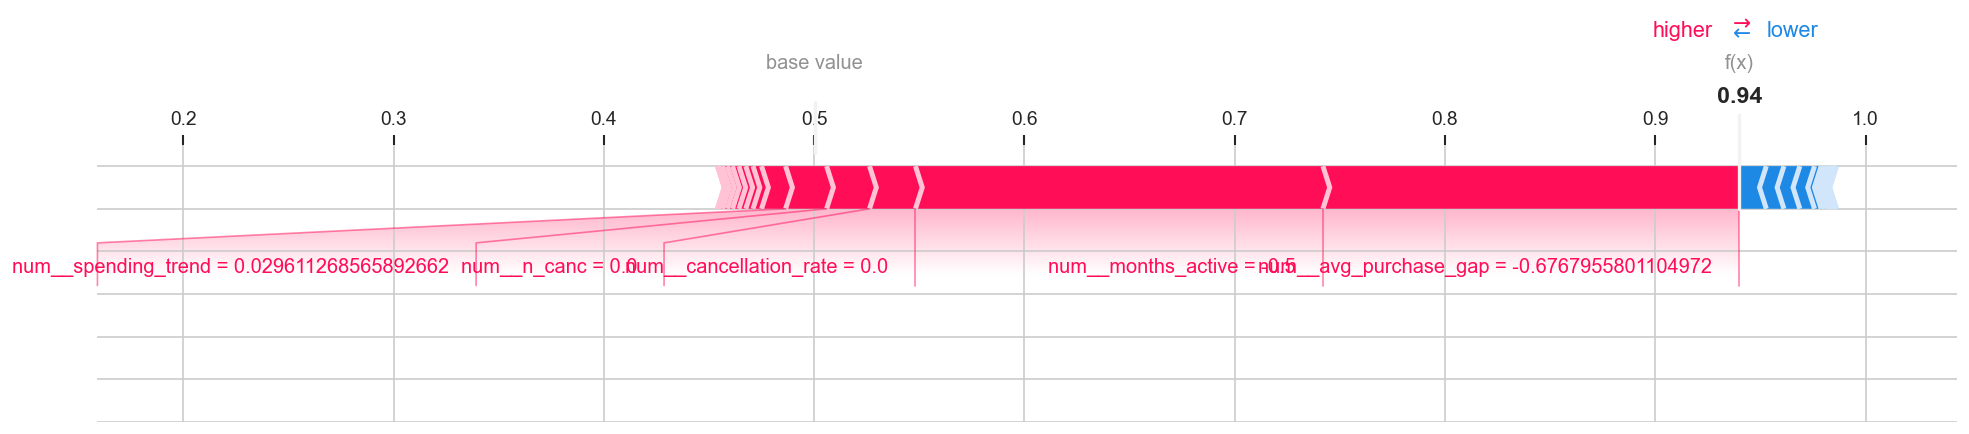


💬 Force plot: This shows why the model gave client 10836 the highest reactivation score. Red features push the score up (toward reactivation), blue features push it down. The base value is the average prediction across all clients.


In [17]:
feature_names_out = NUMERIC_FEATURES + CATEGORICAL_FEATURES

best_pipeline = fitted_models[best_model_name]
fitted_model = best_pipeline.named_steps['model']

# ── Helpers for OHE-aware SHAP ──────────────────────────────────────
def _get_shap_feature_names(prep_fitted):
    """Get feature names from the fitted preprocessor's transformed output."""
    try:
        return list(prep_fitted.get_feature_names_out())
    except AttributeError:
        return feature_names_out

def _aggregate_shap_to_original(shap_vals, transformed_names, original_names):
    """Aggregate |SHAP| from OHE-expanded columns back to original features."""
    aggregated = {}
    for feat in original_names:
        matching_cols = [i for i, name in enumerate(transformed_names)
                         if name == f'num__{feat}'
                         or name == f'cat__{feat}'
                         or name.startswith(f'cat__{feat}_')]
        if matching_cols:
            aggregated[feat] = np.abs(shap_vals[:, matching_cols]).sum(axis=1).mean()
        else:
            aggregated[feat] = 0.0
    return pd.Series(aggregated)

# ── Part A: Permutation importance (model-agnostic, unbiased) ─────────
X_test_feat = X_test[feature_names_out]

perm_result = permutation_importance(
    best_pipeline, X_test_feat, y_test,
    scoring='roc_auc',  # AUC used here: more stable for feature ranking than AP
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm_result.importances_mean,
    index=feature_names_out
).sort_values(ascending=False)

importance_std = pd.Series(
    perm_result.importances_std,
    index=feature_names_out
)

# ── Part B: SHAP analysis (on full-feature model) ────────────────────
import sklearn

prep_fitted = best_pipeline.named_steps['prep']
X_transformed = prep_fitted.transform(model)

sample_size = min(1000, X_transformed.shape[0])
np.random.seed(42)
sample_indices = np.random.choice(X_transformed.shape[0], sample_size, replace=False)
X_transformed_sample = X_transformed[sample_indices]

if isinstance(fitted_model, sklearn.linear_model.LogisticRegression):
    explainer = shap.LinearExplainer(fitted_model, X_transformed_sample)
else:
    explainer = shap.TreeExplainer(fitted_model)

shap_values = explainer.shap_values(X_transformed_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
if hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap_feature_names = _get_shap_feature_names(prep_fitted)

shap.summary_plot(
    shap_values, X_transformed_sample,
    feature_names=shap_feature_names,
    show=True, plot_size=(10, 7)
)

print('\n\U0001F4AC SHAP summary: Each dot is one client. Features at the top have the strongest influence on the model\'s predictions.')

# ── Part C: Cross-reference — Permutation vs SHAP vs Target ─────────
# Three independent methods ranked side-by-side to validate feature selection.

if len(shap_feature_names) != len(feature_names_out):
    # OHE active — aggregate back to original feature level
    shap_importance = _aggregate_shap_to_original(
        shap_values, shap_feature_names, feature_names_out
    ).sort_values(ascending=False)
else:
    shap_importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=feature_names_out
    ).sort_values(ascending=False)

# Combine target association: |point-biserial r| for numeric, Cramér's V for categorical
target_assoc = pd.Series(dtype=float)
for feat in feature_names_out:
    if feat in target_corr_df.index:
        target_assoc[feat] = abs(target_corr_df.loc[feat, 'correlation'])
    elif feat in cat_corr_df.index:
        target_assoc[feat] = cat_corr_df.loc[feat, 'cramers_v']
    else:
        target_assoc[feat] = np.nan

# Rank all three (1 = most important)
perm_rank  = importances.rank(ascending=False).astype(int)
shap_rank  = shap_importance.rank(ascending=False).astype(int)
assoc_rank = target_assoc.rank(ascending=False, na_option='bottom').astype(int)

# Selection criterion: must pass BOTH gates (same as Part D)
n_features_total = len(feature_names_out)
perm_pass = (importances - 2 * importance_std) > 0
shap_pass = shap_rank <= n_features_total // 2
is_selected = perm_pass & shap_pass

cross_ref = pd.DataFrame({
    'Perm. Imp.':    importances,
    'Perm. Rank':    perm_rank,
    'Mean |SHAP|':   shap_importance,
    'SHAP Rank':     shap_rank,
    'Target Assoc.': target_assoc,
    'Assoc. Rank':   assoc_rank,
    'Selected':      is_selected.map({True: '\u2713', False: ''})
}, index=feature_names_out).sort_values('Perm. Rank')

print('=' * 90)
print('CROSS-REFERENCE: Feature Rankings by Three Independent Methods')
print('=' * 90)
print(cross_ref.to_string())

# Agreement summary
top_k = int(is_selected.sum())
perm_top  = set(importances.head(top_k).index)
shap_top  = set(shap_importance.head(top_k).index)
assoc_top = set(target_assoc.sort_values(ascending=False).head(top_k).dropna().index)

perm_shap_overlap  = len(perm_top & shap_top)
perm_assoc_overlap = len(perm_top & assoc_top)
all_three_overlap  = len(perm_top & shap_top & assoc_top)

print(f'\nAgreement (top-{top_k} overlap):')
print(f'  Permutation importance vs SHAP:              {perm_shap_overlap}/{top_k} features agree')
print(f'  Permutation importance vs target association: {perm_assoc_overlap}/{top_k} features agree')
print(f'  All three methods:                            {all_three_overlap}/{top_k} features agree')
print()
print('Note: Target association = |point-biserial r| for numeric, Cram\u00e9r\'s V for categorical.')
print('      These are different scales and not directly comparable \u2014 the ranking is directional only.')
print()
print('\U0001F4AC Cross-reference: This table shows that multiple independent methods agree on which features matter \u2014 the selection is not based on a single metric.')

# ── Part D: Feature selection — dual criterion ───────────────────────
# Gate 1: Permutation importance 95% CI > 0 (statistically significant)
# Gate 2: SHAP rank in top half (model actually uses this feature)
# A feature must pass BOTH gates to be selected.
n_features = len(feature_names_out)
shap_cutoff = n_features // 2  # top half = rank 1..17

signal_df = pd.DataFrame({
    'importance': importances,
    'std': importance_std[importances.index],
})
signal_df['lower_95ci'] = signal_df['importance'] - 2 * signal_df['std']
signal_df['perm_pass'] = signal_df['lower_95ci'] > 0
signal_df['shap_rank'] = shap_rank
signal_df['shap_pass'] = shap_rank <= shap_cutoff
signal_df['selected'] = signal_df['perm_pass'] & signal_df['shap_pass']

# Classify for display
def _label(row):
    if row['selected']:
        return 'Keep'
    elif row['perm_pass'] and not row['shap_pass']:
        return 'Drop (SHAP disagrees)'
    else:
        return 'Drop'
signal_df['signal'] = signal_df.apply(_label, axis=1)

n_keep = signal_df['selected'].sum()
n_drop = (~signal_df['selected']).sum()

# ── Visualization ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
top_n = importances.head(18)
top_n_std = importance_std[top_n.index]
colors = ['#185FA5' if signal_df.loc[f, 'selected'] else '#B4B2A9'
          for f in top_n.index]
ax.barh(
    top_n.index[::-1], top_n.values[::-1],
    xerr=top_n_std.values[::-1],
    color=colors[::-1],
    capsize=3, ecolor='#666666'
)
ax.set_xlabel('Permutation importance (drop in AUC)')
ax.set_title(f'Top 18 features \u2014 {best_model_name} \u00b7 Pass 1, all {len(feature_names_out)} features (blue = selected)', fontsize=11)
plt.tight_layout()
plt.show()

print('\n\U0001F4AC Importance chart: The blue bars are features that passed our selection criteria. The grey bars were not statistically significant.')

print('\nTop 10 features (permutation importance \u00b1 std):')
top10 = pd.DataFrame({
    'importance': importances.head(10),
    'std': importance_std[importances.head(10).index]
})
print(top10.to_string())

# ── Feature selection summary ────────────────────────────────────────
print('\n' + '=' * 70)
print('FEATURE SELECTION (95% CI + SHAP top-half confirmation)')
print('=' * 70)
print(signal_df.to_string())
print(f'\n  Keep (statistically significant): {n_keep}')
print(f'  Drop (CI includes zero):          {n_drop}')

# Store selected features for retraining
SELECTED_FEATURES = signal_df[signal_df['selected']].index.tolist()
SELECTED_NUMERIC = [f for f in SELECTED_FEATURES if f in NUMERIC_FEATURES]
SELECTED_CATEGORICAL = [f for f in SELECTED_FEATURES if f in CATEGORICAL_FEATURES]

print(f'\n  Selected numeric features ({len(SELECTED_NUMERIC)}): {SELECTED_NUMERIC}')
print(f'  Selected categorical features ({len(SELECTED_CATEGORICAL)}): {SELECTED_CATEGORICAL}')
print(f'\n  \u2192 These {n_keep} features will be used for model retraining in the next section.')
print()
print('\U0001F4AC Feature selection: We kept only features that are both statistically significant AND confirmed by SHAP as important to the model.')

# ── Part E: SHAP force plot (individual client explanation) ──────────
import sklearn

prep_fitted = best_pipeline.named_steps['prep']
X_transformed = prep_fitted.transform(model)

top_client_idx = best_probs.argmax()
single_client_features_2d = X_transformed[top_client_idx].reshape(1, -1)

if isinstance(fitted_model, sklearn.linear_model.LogisticRegression):
    explainer = shap.LinearExplainer(fitted_model, X_transformed)
else:
    explainer = shap.TreeExplainer(fitted_model)

single_shap_values = explainer.shap_values(single_client_features_2d)

raw_base = explainer.expected_value
if isinstance(raw_base, (list, np.ndarray)):
    base_val = float(raw_base[1]) if len(raw_base) > 1 else float(raw_base[0])
else:
    base_val = float(raw_base)

if isinstance(single_shap_values, list):
    single_shap_1d = single_shap_values[1][0]
else:
    if len(single_shap_values.shape) == 3:
        single_shap_1d = single_shap_values[0, :, 1]
    else:
        single_shap_1d = single_shap_values[0]

single_features_1d = single_client_features_2d[0]

print(f'Client index: {top_client_idx}  |  Score: {best_probs[top_client_idx]:.3f}  |  Actual target: {y.iloc[top_client_idx]}')

shap.force_plot(
    base_val,
    single_shap_1d,
    single_features_1d,
    feature_names=shap_feature_names,
    matplotlib=True
)
plt.show()


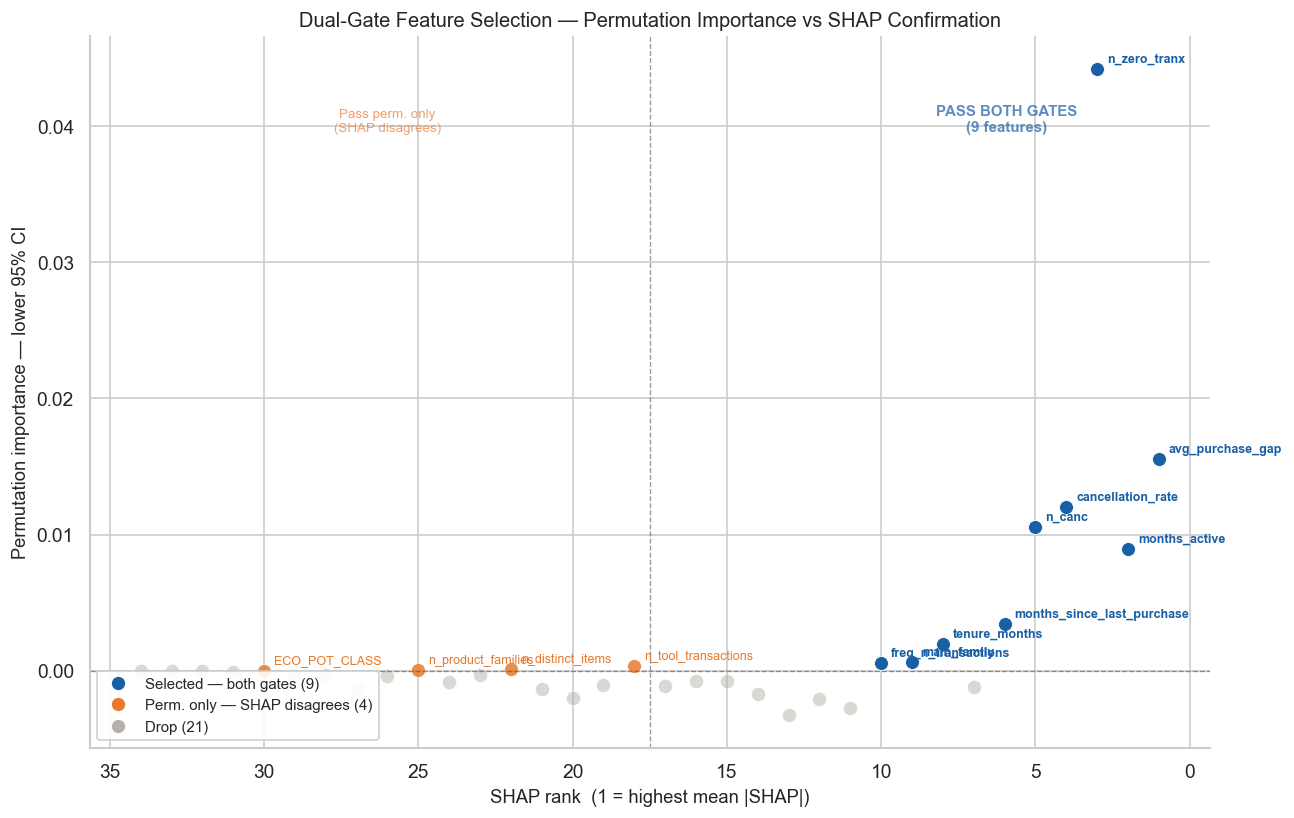

Dual-gate results (34 features evaluated):
  Gate 1 — Permutation importance (95% CI > 0):  13 pass
  Gate 2 — SHAP top half (rank <= 17):          17 pass
  Both gates (intersection):                      9 pass

  Dropped by SHAP disagreement (4):
    n_tool_transactions             perm_rank=10  shap_rank=18
    n_distinct_items                perm_rank=11  shap_rank=22
    n_product_families              perm_rank=12  shap_rank=25
    ECO_POT_CLASS                   perm_rank=18  shap_rank=30

  Final selected features (9):
    n_zero_tranx                    perm_rank= 1  shap_rank= 3
    cancellation_rate               perm_rank= 2  shap_rank= 4
    n_canc                          perm_rank= 3  shap_rank= 5
    avg_purchase_gap                perm_rank= 4  shap_rank= 1
    months_active                   perm_rank= 5  shap_rank= 2
    months_since_last_purchase      perm_rank= 6  shap_rank= 6
    tenure_months                   perm_rank= 7  shap_rank= 8
    main_family          

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# DUAL-GATE VISUALIZATION — Which features pass both selection criteria?
# ══════════════════════════════════════════════════════════════════════════
# Scatter plot: each feature positioned by its SHAP rank (x) and
# permutation importance lower 95% CI (y). Only features in the top-left
# quadrant (significant permutation importance AND top-half SHAP) survive.

BLUE   = '#185FA5'
ORANGE = '#E8792B'
GRAY   = '#B4B2A9'

fig, ax = plt.subplots(figsize=(11, 7))

for feat in signal_df.index:
    sx = signal_df.loc[feat, 'shap_rank']
    sy = signal_df.loc[feat, 'lower_95ci']
    selected = signal_df.loc[feat, 'selected']
    shap_disagree = signal_df.loc[feat, 'perm_pass'] and not signal_df.loc[feat, 'shap_pass']

    if selected:
        color, zorder, alpha = BLUE, 3, 1.0
    elif shap_disagree:
        color, zorder, alpha = ORANGE, 2, 0.85
    else:
        color, zorder, alpha = GRAY, 1, 0.5

    ax.scatter(sx, sy, color=color, s=70, zorder=zorder, alpha=alpha,
               edgecolors='white', linewidth=0.5)

    # Label selected and SHAP-disagree features; skip the grey noise
    if selected or shap_disagree:
        ax.annotate(
            feat, (sx, sy),
            textcoords='offset points', xytext=(6, 4),
            fontsize=7.5, color=color,
            fontweight='bold' if selected else 'normal',
        )

# Gate boundaries
shap_cutoff = len(signal_df) // 2
ax.axvline(x=shap_cutoff + 0.5, color='#555555', linestyle='--', linewidth=0.8,
           alpha=0.6, label=f'SHAP cutoff (rank {shap_cutoff})')
ax.axhline(y=0, color='#555555', linestyle='--', linewidth=0.8, alpha=0.6,
           label='Perm. importance 95% CI = 0')

# Quadrant labels
ylim = ax.get_ylim()
ax.text(shap_cutoff * 0.35, ylim[1] * 0.85,
        f'PASS BOTH GATES\n({int(signal_df["selected"].sum())} features)',
        fontsize=9, fontweight='bold', color=BLUE, ha='center', alpha=0.7)
ax.text(shap_cutoff * 1.5 + 0.5, ylim[1] * 0.85,
        'Pass perm. only\n(SHAP disagrees)',
        fontsize=8, color=ORANGE, ha='center', alpha=0.7)

ax.set_xlabel('SHAP rank  (1 = highest mean |SHAP|)', fontsize=11)
ax.set_ylabel('Permutation importance — lower 95% CI', fontsize=11)
ax.set_title('Dual-Gate Feature Selection — Permutation Importance vs SHAP Confirmation',
             fontsize=12)
ax.invert_xaxis()  # rank 1 on the left (best SHAP → left side)

# Legend
from matplotlib.lines import Line2D
n_selected = int(signal_df['selected'].sum())
n_shap_disagree = int((signal_df['perm_pass'] & ~signal_df['shap_pass']).sum())
n_drop = len(signal_df) - n_selected - n_shap_disagree

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=BLUE,
           markersize=9, label=f'Selected — both gates ({n_selected})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ORANGE,
           markersize=9, label=f'Perm. only — SHAP disagrees ({n_shap_disagree})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GRAY,
           markersize=9, label=f'Drop ({n_drop})'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# ── Summary: what passed, what got dropped by SHAP ──────────────────
shap_disagree_list = signal_df[signal_df['perm_pass'] & ~signal_df['shap_pass']].index.tolist()
selected_list = signal_df[signal_df['selected']].index.tolist()

print(f'Dual-gate results ({len(signal_df)} features evaluated):')
print(f'  Gate 1 — Permutation importance (95% CI > 0):  {int(signal_df["perm_pass"].sum())} pass')
print(f'  Gate 2 — SHAP top half (rank <= {shap_cutoff}):          {int(signal_df["shap_pass"].sum())} pass')
print(f'  Both gates (intersection):                      {n_selected} pass')
print(f'\n  Dropped by SHAP disagreement ({n_shap_disagree}):')
for f in shap_disagree_list:
    print(f'    {f:30s}  perm_rank={list(signal_df.index).index(f)+1:2d}  shap_rank={int(signal_df.loc[f, "shap_rank"]):2d}')
print(f'\n  Final selected features ({n_selected}):')
for f in selected_list:
    print(f'    {f:30s}  perm_rank={list(signal_df.index).index(f)+1:2d}  shap_rank={int(signal_df.loc[f, "shap_rank"]):2d}')


## Feature Selection & Model Retraining (Pass 2)

Retrains all models using only the features that passed both selection gates. Fewer features, same or better performance, and easier to interpret.

In [19]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE SELECTION & MODEL RETRAINING (PASS 2)
# ══════════════════════════════════════════════════════════════════════════
# Retrain all models using only features that passed dual selection (95% CI + SHAP).
# Primary metric: Average Precision (AP).

print(f'Pass 1 (all features):      {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)} features')
print(f'Pass 2 (selected features): {len(SELECTED_NUMERIC) + len(SELECTED_CATEGORICAL)} features')
print(f'  Numeric:     {SELECTED_NUMERIC}')
print(f'  Categorical: {SELECTED_CATEGORICAL}')
print()

# ── Rebuild preprocessor with selected features ─────────────────────────
sel_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, SELECTED_NUMERIC),
    ('cat', categorical_transformer, SELECTED_CATEGORICAL)
])
sel_preprocessor_ohe = ColumnTransformer([
    ('num', numeric_transformer, SELECTED_NUMERIC),
    ('cat', categorical_transformer_ohe, SELECTED_CATEGORICAL)
])

# ── Rebuild model pipelines using canonical factory ──
sel_models = make_model_dict(sel_preprocessor, sel_preprocessor_ohe)

try:
    _sel_us_ratios = us_best_ratios
    for mname, ratio in _sel_us_ratios.items():
        label = 'None (full data)' if ratio is None else f'1:{int(ratio) if ratio == int(ratio) else ratio}'
except NameError:
    _sel_us_ratios = {name: None for name in sel_models}
print()

# ── Step 1: 5-fold CV with per-model undersampling ──────────────────
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

sel_cv_results = {}
for name, pipeline in sel_models.items():
    ratio = _sel_us_ratios.get(name)
    ratio_label = 'no US' if ratio is None else f'1:{int(ratio) if ratio == int(ratio) else ratio}'

    fold_aucs, fold_aps = [], []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(model, y)):
        X_tr_fold, y_tr_fold = model.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = model.iloc[val_idx], y.iloc[val_idx]

        if ratio is not None:
            np.random.seed(RANDOM_STATE + fold_i)
            X_tr_fold, y_tr_fold = undersample(X_tr_fold, y_tr_fold, ratio)

        fold_pipe = clone(pipeline)
        fold_pipe.fit(X_tr_fold, y_tr_fold)
        val_probs = fold_pipe.predict_proba(X_val_fold)[:, 1]
        fold_aucs.append(roc_auc_score(y_val_fold, val_probs))
        fold_aps.append(average_precision_score(y_val_fold, val_probs))

    sel_cv_results[name] = {
        'AP_mean': np.mean(fold_aps),
        'AP_std': np.std(fold_aps),
        'AUC_mean': np.mean(fold_aucs),
        'AUC_std': np.std(fold_aucs),
        'US_ratio': ratio_label,
    }
    print(f'  AP = {sel_cv_results[name]["AP_mean"]:.4f} \u00b1 {sel_cv_results[name]["AP_std"]:.4f}  |  '
          f'AUC = {sel_cv_results[name]["AUC_mean"]:.4f} \u00b1 {sel_cv_results[name]["AUC_std"]:.4f}')

sel_results_df = pd.DataFrame(sel_cv_results).T.sort_values('AP_mean', ascending=False)
print()
print(sel_results_df)

sel_best_model_name = sel_results_df.index[0]
sel_best_us_ratio = _sel_us_ratios.get(sel_best_model_name)
print(f'\nBest model (Pass 2, by AP): {sel_best_model_name}  '
      f'(AP = {sel_cv_results[sel_best_model_name]["AP_mean"]:.4f} '
      f'\u00b1 {sel_cv_results[sel_best_model_name]["AP_std"]:.4f})')

# ── Compare Pass 1 vs Pass 2 on AP ─────────────────────────────────
p1_ap = cv_results[results_df.index[0]]['AP_mean']
p2_ap = sel_cv_results[sel_best_model_name]['AP_mean']
p1_auc = cv_results[results_df.index[0]]['AUC_mean']
p2_auc = sel_cv_results[sel_best_model_name]['AUC_mean']
delta_ap = p2_ap - p1_ap

print(f'\nPass 1 ({results_df.index[0]}, {len(feature_names_out)} features): AP = {p1_ap:.4f} | AUC = {p1_auc:.4f}')
print(f'Pass 2 ({sel_best_model_name}, {len(SELECTED_FEATURES)} features): AP = {p2_ap:.4f} | AUC = {p2_auc:.4f}')
print(f'Delta AP: {delta_ap:+.4f}')
if delta_ap >= -0.005:
    print('\u2192 Feature reduction successful \u2014 performance maintained with fewer features.')
else:
    print('\u2192 Warning: noticeable AP drop. Consider keeping more features.')

# ── Step 2: Train/test split + fit ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    model, y, test_size=0.20, shuffle=True, stratify=y, random_state=RANDOM_STATE
)

fitted_models = {}
for name, pipeline in sel_models.items():
    ratio = _sel_us_ratios.get(name)
    if ratio is not None:
        np.random.seed(RANDOM_STATE)
        X_train_fit, y_train_fit = undersample(X_train, y_train, ratio)
    else:
        X_train_fit, y_train_fit = X_train, y_train
    pipeline.fit(X_train_fit, y_train_fit)
    fitted_models[name] = pipeline

# Overwrite key variables for downstream cells
best_model_name = sel_best_model_name
best_model = fitted_models[best_model_name]

# ── Step 3: Held-out test evaluation ─────────────────────────────────
test_probs = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)

print()
print('Held-out TEST performance (Pass 2, 20%)')
print(f'  AP = {test_ap:.4f}  |  AUC = {test_auc:.4f}')

# ── Step 4: Out-of-fold scoring ──────────────────────────────────────
cv_oof = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

oof_probs = np.zeros(len(y))
for fold_i, (train_idx, val_idx) in enumerate(cv_oof.split(model, y)):
    X_tr_fold = model.iloc[train_idx]
    y_tr_fold = y.iloc[train_idx]
    if sel_best_us_ratio is not None:
        np.random.seed(RANDOM_STATE + fold_i)
        X_tr_fold, y_tr_fold = undersample(X_tr_fold, y_tr_fold, sel_best_us_ratio)
    fold_pipe = clone(sel_models[sel_best_model_name])
    fold_pipe.fit(X_tr_fold, y_tr_fold)
    oof_probs[val_idx] = fold_pipe.predict_proba(model.iloc[val_idx])[:, 1]
best_probs = oof_probs

print(f'Out-of-fold scores recomputed for {len(best_probs):,} clients')

Pass 1 (all features):      34 features
Pass 2 (selected features): 9 features
  Numeric:     ['n_zero_tranx', 'cancellation_rate', 'n_canc', 'avg_purchase_gap', 'months_active', 'months_since_last_purchase', 'tenure_months', 'freq_n_transactions']
  Categorical: ['main_family']

Per-model undersampling ratios (from Cell 29):
  Logistic Regression: 1:4
  Random Forest: 1:2.5
  LGBM: 1:2
  XGB: 1:5
  Extra Trees: 1:5

Cross-validating Logistic Regression (ratio: 1:4)...


  AP = 0.4189 ± 0.0217  |  AUC = 0.7912 ± 0.0074
Cross-validating Random Forest (ratio: 1:2.5)...


  AP = 0.6868 ± 0.0158  |  AUC = 0.8658 ± 0.0100
Cross-validating LGBM (ratio: 1:2)...
[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 888
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

  AP = 0.6778 ± 0.0146  |  AUC = 0.8617 ± 0.0097

                      AP_mean    AP_std  AUC_mean   AUC_std US_ratio
Random Forest        0.686778  0.015787  0.865843  0.009963    1:2.5
Extra Trees          0.677799  0.014639  0.861719  0.009664      1:5
XGB                  0.668305  0.016455  0.852409  0.006369      1:5
LGBM                 0.665557  0.016557  0.846716  0.009983      1:2
Logistic Regression  0.418944  0.021673  0.791216  0.007441      1:4

Best model (Pass 2, by AP): Random Forest  (AP = 0.6868 ± 0.0158)

Pass 1 (Random Forest, 34 features): AP = 0.6817 | AUC = 0.8610
Pass 2 (Random Forest, 9 features): AP = 0.6868 | AUC = 0.8658
Delta AP: +0.0050
→ Feature reduction successful — performance maintained with fewer features.


[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf



Held-out TEST performance (Pass 2, 20%)
  AP = 0.6684  |  AUC = 0.8616


Out-of-fold scores recomputed for 14,943 clients


## Hyperparameter Tuning (Optuna)

Bayesian optimisation (50 trials each) on Random Forest and Extra Trees — the top 2 models from Pass 2. Tunes model hyperparameters and undersampling ratio jointly, optimising for Average Precision via 5-fold CV.

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# HYPERPARAMETER TUNING (OPTUNA)
# ══════════════════════════════════════════════════════════════════════════
# Bayesian optimisation (TPE) on Random Forest and Extra Trees.
# Optimises AP via 5-fold Stratified CV with per-fold undersampling.
# The undersampling ratio is tuned jointly with model hyperparameters.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50
TUNING_MODELS = ['Random Forest', 'Extra Trees']


def optuna_objective(trial, model_name):
    """Optuna objective: 5-fold CV Average Precision with per-fold undersampling."""

    # ── Common hyperparameters ──
    max_depth         = trial.suggest_int('max_depth', 8, 25)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7])
    criterion         = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    common_kw = dict(
        n_estimators=500, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features, criterion=criterion,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
    )

    if model_name == 'Random Forest':
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])
        us_ratio  = trial.suggest_float('us_ratio', 1.5, 5.0, step=0.5)
        clf = RandomForestClassifier(bootstrap=bootstrap, **common_kw)
    else:  # Extra Trees
        us_ratio  = trial.suggest_float('us_ratio', 2.0, 8.0, step=0.5)
        clf = ExtraTreesClassifier(**common_kw)

    pipe = Pipeline([('prep', clone(sel_preprocessor)), ('model', clf)])

    # ── 5-fold CV (same folds as Pass 2) ──
    cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    fold_aps = []
    for fold_i, (train_idx, val_idx) in enumerate(cv.split(model, y)):
        X_tr, y_tr = model.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = model.iloc[val_idx], y.iloc[val_idx]

        np.random.seed(RANDOM_STATE + fold_i)
        X_tr, y_tr = undersample(X_tr, y_tr, us_ratio)

        fold_pipe = clone(pipe)
        fold_pipe.fit(X_tr, y_tr)
        val_probs = fold_pipe.predict_proba(X_val)[:, 1]
        fold_aps.append(average_precision_score(y_val, val_probs))

    return np.mean(fold_aps)



Optuna objective defined — 50 trials per model
Models to tune: ['Random Forest', 'Extra Trees']
Features: 9 (8 numeric + 1 categorical)


In [21]:
# ── Run Optuna studies ────────────────────────────────────────────────────────────

studies = {}
for mname in TUNING_MODELS:
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=mname,
    )
    study.optimize(
        lambda trial, m=mname: optuna_objective(trial, m),
        n_trials=N_TRIALS,
        show_progress_bar=True,
    )
    studies[mname] = study
    print(f'{mname}: best AP = {study.best_value:.4f} (trial {study.best_trial.number})')

# ── Before vs After comparison ────────────────────────────────────────────────
print()
print('=' * 70)
print('HYPERPARAMETER TUNING RESULTS')
print('=' * 70)

comparison_rows = []
for mname in TUNING_MODELS:
    baseline_ap = sel_cv_results[mname]['AP_mean']
    tuned_ap    = studies[mname].best_value
    delta       = tuned_ap - baseline_ap
    comparison_rows.append({
        'Model': mname,
        'AP (hand-tuned)': baseline_ap,
        'AP (Optuna)': tuned_ap,
        'Delta': delta,
    })

tuning_df = pd.DataFrame(comparison_rows).set_index('Model')
print(tuning_df.to_string(float_format='{:.4f}'.format))
print()

# ── Select champion ───────────────────────────────────────────────────────────
champion_name = max(TUNING_MODELS, key=lambda m: studies[m].best_value)
champion_params = studies[champion_name].best_params.copy()
champion_us_ratio = champion_params.pop('us_ratio')

print(f'Champion: {champion_name} (AP = {studies[champion_name].best_value:.4f})')
print(f'Best hyperparameters: {champion_params}')
print(f'Best undersampling ratio: 1:{champion_us_ratio}')
print()

# ── Rebuild champion pipeline with tuned params ───────────────────────────
if champion_name == 'Random Forest':
    tuned_clf = RandomForestClassifier(
        n_estimators=500, **champion_params,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
    )
else:
    tuned_clf = ExtraTreesClassifier(
        n_estimators=500, **champion_params,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
    )

tuned_pipeline = Pipeline([('prep', clone(sel_preprocessor)), ('model', tuned_clf)])

# ── Overwrite fitted_models (champion entry gets tuned params) ────────────
fitted_models = {}
for name, pipeline in sel_models.items():
    if name == champion_name:
        pipe_to_fit = clone(tuned_pipeline)
        ratio = champion_us_ratio
    else:
        pipe_to_fit = clone(pipeline)
        ratio = _sel_us_ratios.get(name)

    if ratio is not None:
        np.random.seed(RANDOM_STATE)
        X_train_fit, y_train_fit = undersample(X_train, y_train, ratio)
    else:
        X_train_fit, y_train_fit = X_train, y_train

    pipe_to_fit.fit(X_train_fit, y_train_fit)
    fitted_models[name] = pipe_to_fit

# ── Overwrite downstream variables ─────────────────────────────────────────
best_model_name = champion_name
best_model = fitted_models[best_model_name]

test_probs = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)

print(f'Held-out TEST performance (tuned {champion_name})')
print(f'  AP = {test_ap:.4f}  |  AUC = {test_auc:.4f}')

# ── Recompute OOF scores with tuned champion ─────────────────────────────
cv_oof = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros(len(y))
for fold_i, (train_idx, val_idx) in enumerate(cv_oof.split(model, y)):
    X_tr_fold = model.iloc[train_idx]
    y_tr_fold = y.iloc[train_idx]
    np.random.seed(RANDOM_STATE + fold_i)
    X_tr_fold, y_tr_fold = undersample(X_tr_fold, y_tr_fold, champion_us_ratio)
    fold_pipe = clone(tuned_pipeline)
    fold_pipe.fit(X_tr_fold, y_tr_fold)
    oof_probs[val_idx] = fold_pipe.predict_proba(model.iloc[val_idx])[:, 1]
best_probs = oof_probs

# ── Update sel_results_df so downstream cells pick up tuned AP ────────────
sel_cv_results[champion_name]['AP_mean'] = studies[champion_name].best_value
sel_results_df = pd.DataFrame(sel_cv_results).T.sort_values('AP_mean', ascending=False)

print(f'Out-of-fold scores recomputed for {len(best_probs):,} clients')
print()

  0%|          | 0/50 [00:00<?, ?it/s]

Random Forest: best AP = 0.6909 (trial 22)


  0%|          | 0/50 [00:00<?, ?it/s]

Extra Trees: best AP = 0.6849 (trial 29)

HYPERPARAMETER TUNING RESULTS
               AP (hand-tuned)  AP (Optuna)  Delta
Model                                             
Random Forest           0.6868       0.6909 0.0041
Extra Trees             0.6778       0.6849 0.0071

Champion: Random Forest (AP = 0.6909)
Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 12, 'min_samples_split': 24, 'max_features': 0.7, 'criterion': 'entropy', 'bootstrap': True}
Best undersampling ratio: 1:2.5



[LightGBM] [Info] Number of positive: 1635, number of negative: 3270
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 893
[LightGBM] [Info] Number of data points in the train set: 4905, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Held-out TEST performance (tuned Random Forest)
  AP = 0.6697  |  AUC = 0.8611


Out-of-fold scores recomputed for 14,943 clients

All downstream variables updated — evaluation cells will use the tuned champion.


## Evaluation — Presentation-Ready Visuals

Four charts summarising model performance:
1. Model comparison bar chart (AP + AUC)
2. Precision-Recall curve for the best model
3. Cumulative Gains curve
4. Campaign ROI table

In [22]:
# ══════════════════════════════════════════════════════════════════════════
# EVALUATION — DATA PREPARATION
# ══════════════════════════════════════════════════════════════════════════

# ── ROI PARAMETERS (data-driven) ──
# Value: median target-period spend of reactivated customers.
#   Median is more robust than mean for skewed B2B spending data.
# Cost: B2B direct marketing benchmark — the client should adjust to actual cost.
reactivated_ids = churned_ids & buyers_future
reactivated_spend = (
    future_sales[future_sales['CLIENT_ID'].isin(reactivated_ids)]
    .groupby('CLIENT_ID')['NET'].sum()
)
VALUE_PER_REACTIVATION = reactivated_spend.median()
COST_PER_CONTACT = 50  # EUR — B2B benchmark (personalised outreach + sales rep time + CRM overhead)

print(f'VALUE_PER_REACTIVATION = {VALUE_PER_REACTIVATION:,.0f} EUR '
      f'(median 6-month spend of {len(reactivated_spend):,} reactivated clients)')
print(f'  Mean: {reactivated_spend.mean():,.0f} EUR | '
      f'Std: {reactivated_spend.std():,.0f} EUR | '
      f'Range: {reactivated_spend.min():,.0f}\u2013{reactivated_spend.max():,.0f} EUR')
print(f'COST_PER_CONTACT = {COST_PER_CONTACT} EUR (B2B benchmark \u2014 adjust to actual cost)')
print()

# ── Sort test set by predicted propensity score (highest first) ──
order = np.argsort(-test_probs)
y_sorted = np.array(y_test)[order]
p_sorted = test_probs[order]

N = len(y_test)
total_pos = int(np.sum(y_sorted))
baseline = total_pos / N

print(f'Test set: {N:,} clients | {total_pos} reactivated ({baseline:.1%} baseline)')
print(f'Best model: {best_model_name}')
print()

# ── Vectorized computation over all K positions (1..N) ──
cum_tp = np.cumsum(y_sorted)
ks_range = np.arange(1, N + 1)

precision_at_k = cum_tp / ks_range
recall_at_k    = cum_tp / total_pos
lift_at_k      = precision_at_k / baseline
cumulative_gain = recall_at_k
profit_at_k    = cum_tp * VALUE_PER_REACTIVATION - ks_range * COST_PER_CONTACT

# Store in a DataFrame for easy access
eval_df = pd.DataFrame({
    'k':          ks_range,
    'k_pct':      ks_range / N,
    'precision':  precision_at_k,
    'recall':     recall_at_k,
    'lift':       lift_at_k,
    'cum_gain':   cumulative_gain,
    'profit':     profit_at_k,
    'cum_tp':     cum_tp,
})

# ── Break-even & peak profit ──
positive_profit = np.where(profit_at_k > 0)[0]
if len(positive_profit) > 0:
    breakeven_k = int(positive_profit[0]) + 1
    peak_k = int(np.argmax(profit_at_k)) + 1
    peak_profit = profit_at_k[peak_k - 1]
    print(f'Break-even K: {breakeven_k} (campaign becomes profitable)')
    print(f'Optimal K:    {peak_k} (maximum profit of {peak_profit:,.0f} EUR)')
else:
    breakeven_k = None
    peak_k = None
    peak_profit = None
    print('WARNING: No campaign size yields positive profit with current ROI parameters.')

# ── PR curve data for all models (needed for visualisation) ──
all_model_names = sel_results_df.index.tolist()
pr_data = {}
model_ap_scores = {}
model_auc_scores = {}

for name in all_model_names:
    try:
        probs_i = fitted_models[name].predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, probs_i)
        ap_i = average_precision_score(y_test, probs_i)
        auc_i = roc_auc_score(y_test, probs_i)
        pr_data[name] = (prec, rec, ap_i)
        model_ap_scores[name] = ap_i
        model_auc_scores[name] = auc_i
    except Exception as e:
        print(f'  Skipping {name}: {e}')


VALUE_PER_REACTIVATION = 383 EUR (median 6-month spend of 2,044 reactivated clients)
  Mean: 772 EUR | Std: 1,180 EUR | Range: 3–21,113 EUR
COST_PER_CONTACT = 50 EUR (B2B benchmark — adjust to actual cost)

Test set: 2,989 clients | 409 reactivated (13.7% baseline)
Best model: Random Forest

Break-even K: 1 (campaign becomes profitable)
Optimal K:    999 (maximum profit of 76,440 EUR)

PR data prepared for 5 models


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


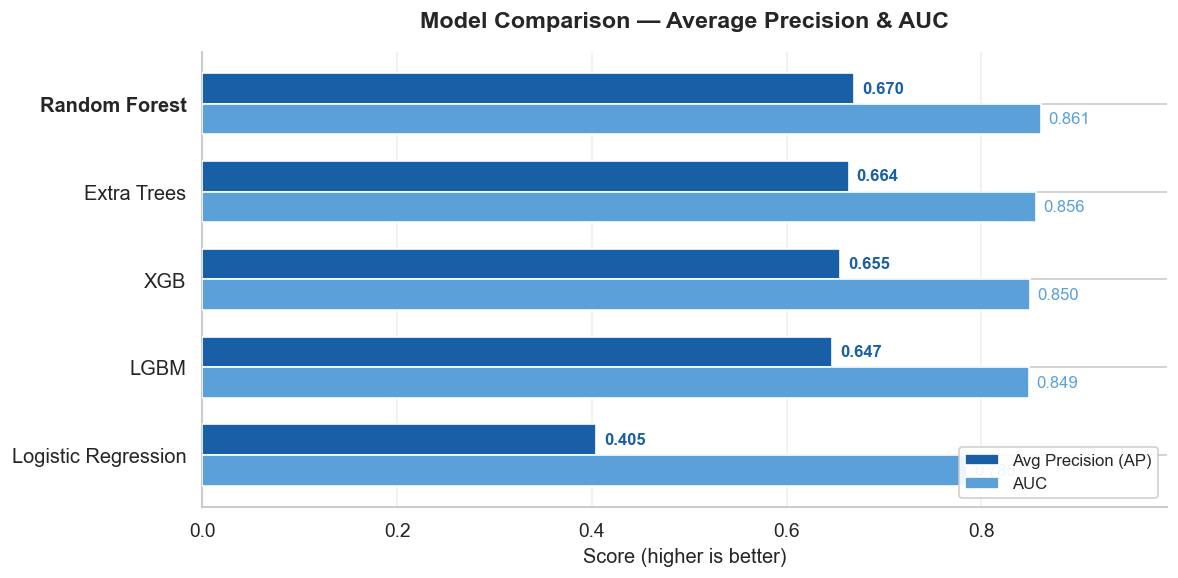


💬 Presenter note: "Random Forest achieves the highest Average Precision (0.670), meaning it is the most reliable at identifying true reactivators among its top predictions."


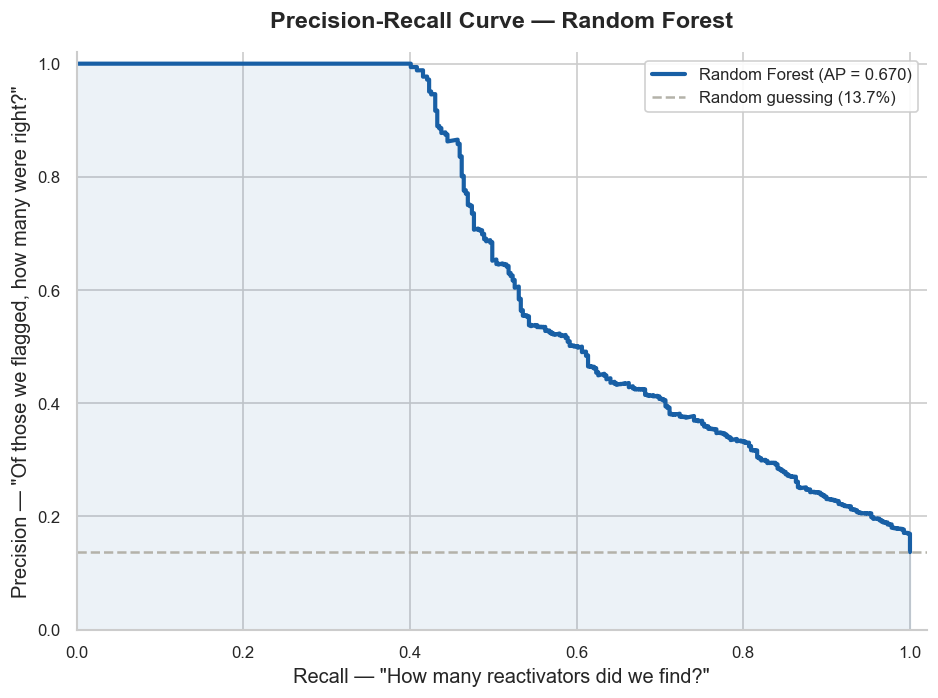


💬 Presenter note: "The curve shows the trade-off between finding more reactivators (recall) and being accurate (precision). Our model stays well above the random baseline (13.7%), which means its predictions are significantly better than guessing."


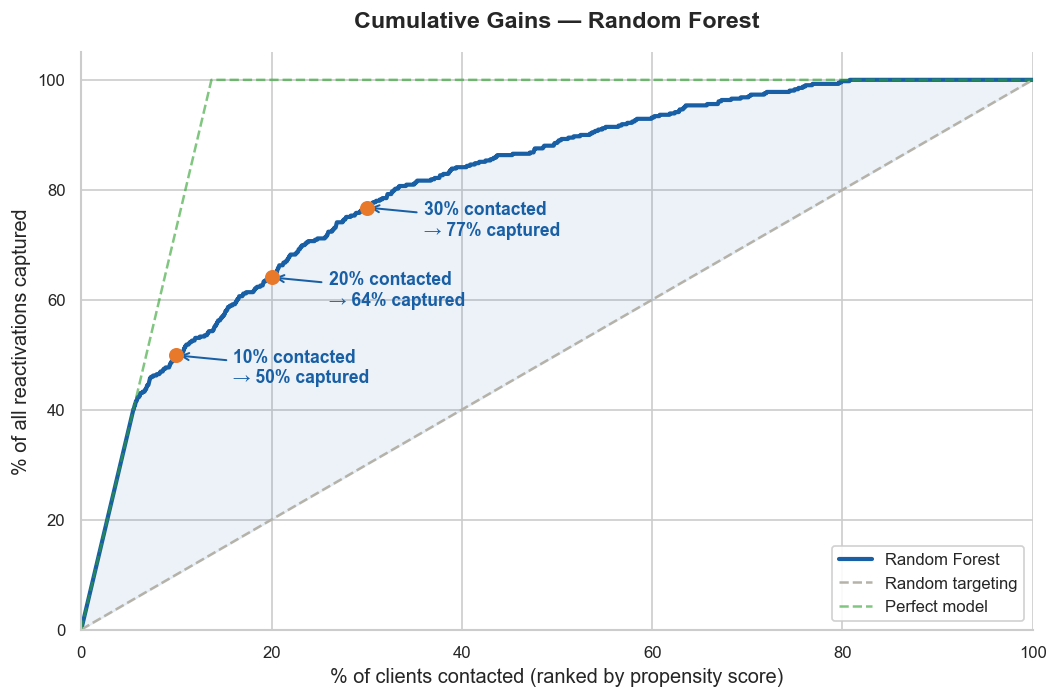


💬 Presenter note: "Instead of contacting all clients, we can focus on the top 20% ranked by the model and still capture about 64% of all potential reactivators — that is the power of targeted outreach vs. random contact."


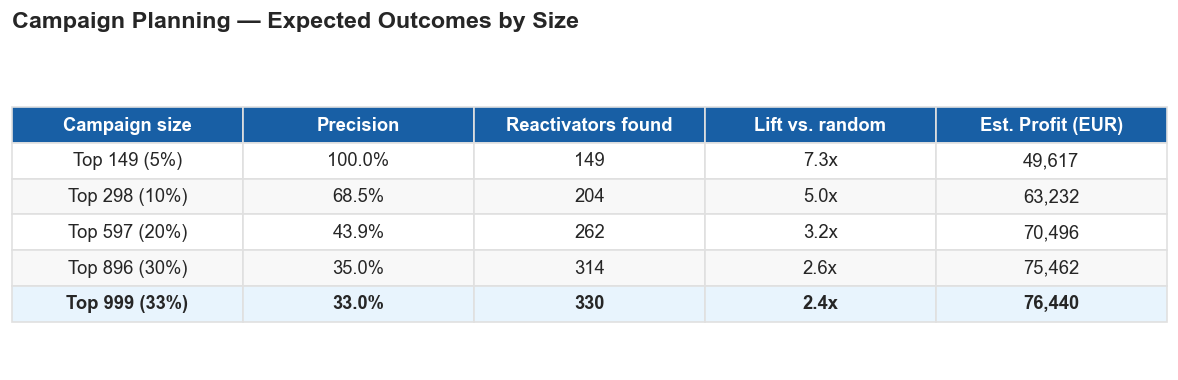


💬 Presenter note: "The highlighted row shows the sweet spot — contacting the top 999 clients (33% of all) is expected to find 330 reactivators and maximise profit at 76,440 EUR."

(ROI parameters: cost per contact = 50 EUR, value per reactivation = 383.0 EUR — update with actual values)


In [23]:
# ══════════════════════════════════════════════════════════════════════════
# EVALUATION — PRESENTATION-READY VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════
# Each chart is designed for a non-technical audience.

# ── Style setup ──
BLUE       = '#185FA5'
BLUE_LIGHT = '#5BA0D9'
ORANGE     = '#E8792B'
GRAY       = '#B4B2A9'
GREEN      = '#2CA02C'
RED        = '#D62728'

FONT_TITLE = 14
FONT_LABEL = 12
FONT_TICK  = 10
FONT_NOTE  = 10.5

# ══════════════════════════════════════════════════════════════════════════
# CHART 1: Model Comparison — Bar Chart (AP + AUC)
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(model_ap_scores.keys())
ap_vals  = [model_ap_scores[n] for n in model_names]
auc_vals = [model_auc_scores[n] for n in model_names]

# Sort by AP (best first)
sort_idx = np.argsort(ap_vals)[::-1]
model_names = [model_names[i] for i in sort_idx]
ap_vals  = [ap_vals[i]  for i in sort_idx]
auc_vals = [auc_vals[i] for i in sort_idx]

y_pos = np.arange(len(model_names))
bar_h = 0.35

bars_ap  = ax.barh(y_pos - bar_h/2, ap_vals,  bar_h, color=BLUE,       label='Avg Precision (AP)', zorder=3)
bars_auc = ax.barh(y_pos + bar_h/2, auc_vals, bar_h, color=BLUE_LIGHT, label='AUC', zorder=3)

# Value labels on bars
for bar in bars_ap:
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=FONT_TICK, fontweight='bold', color=BLUE)
for bar in bars_auc:
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=FONT_TICK, color=BLUE_LIGHT)

# Highlight best model
ax.get_yticklabels()[0].set_fontweight('bold') if hasattr(ax, 'get_yticklabels') else None

ax.set_yticks(y_pos)
ax.set_yticklabels(model_names, fontsize=FONT_LABEL)
ax.set_xlabel('Score (higher is better)', fontsize=FONT_LABEL)
ax.set_title('Model Comparison — Average Precision & AUC', fontsize=FONT_TITLE, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=FONT_TICK, framealpha=0.9)
ax.set_xlim(0, max(max(ap_vals), max(auc_vals)) * 1.15)
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# CHART 2: Precision-Recall Curve (best model only)
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))

best_prec, best_rec, best_ap_val = pr_data[best_model_name]

ax.plot(best_rec, best_prec, color=BLUE, linewidth=2.5,
        label=f'{best_model_name} (AP = {best_ap_val:.3f})')
ax.axhline(y=baseline, linestyle='--', color=GRAY, linewidth=1.5,
           label=f'Random guessing ({baseline:.1%})')

# Fill area under curve for visual impact
ax.fill_between(best_rec, best_prec, alpha=0.08, color=BLUE)

ax.set_xlabel('Recall — "How many reactivators did we find?"', fontsize=FONT_LABEL)
ax.set_ylabel('Precision — "Of those we flagged, how many were right?"', fontsize=FONT_LABEL)
ax.set_title(f'Precision-Recall Curve — {best_model_name}', fontsize=FONT_TITLE, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=FONT_TICK, framealpha=0.9)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# CHART 3: Cumulative Gains Curve (best model only)
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 6))

pct_contacted = eval_df['k_pct'].values * 100
cum_gain_pct  = eval_df['cum_gain'].values * 100

# Perfect model line
perfect_x = [0, baseline * 100, 100]
perfect_y = [0, 100, 100]

ax.plot(pct_contacted, cum_gain_pct, color=BLUE, linewidth=2.5,
        label=f'{best_model_name}')
ax.plot([0, 100], [0, 100], '--', color=GRAY, linewidth=1.5,
        label='Random targeting')
ax.plot(perfect_x, perfect_y, '--', color=GREEN, linewidth=1.5, alpha=0.6,
        label='Perfect model')

# Fill the gain area between model and random
ax.fill_between(pct_contacted, cum_gain_pct, pct_contacted, alpha=0.08, color=BLUE)

# Annotate key points: 10%, 20%, 30% contacted
for pct_target in [10, 20, 30]:
    k_idx = int(pct_target / 100 * N) - 1
    if 0 <= k_idx < N:
        gain_val = eval_df.iloc[k_idx]['cum_gain'] * 100
        ax.plot(pct_target, gain_val, 'o', color=ORANGE, markersize=8, zorder=5)
        ax.annotate(f'{pct_target}% contacted\n\u2192 {gain_val:.0f}% captured',
                    xy=(pct_target, gain_val),
                    xytext=(pct_target + 6, gain_val - 5),
                    fontsize=FONT_NOTE, fontweight='bold', color=BLUE,
                    arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))

ax.set_xlabel('% of clients contacted (ranked by propensity score)', fontsize=FONT_LABEL)
ax.set_ylabel('% of all reactivations captured', fontsize=FONT_LABEL)
ax.set_title(f'Cumulative Gains — {best_model_name}', fontsize=FONT_TITLE, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=FONT_TICK, framealpha=0.9)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════
# CHART 4: Campaign ROI Table (compact, presentation-ready)
# ══════════════════════════════════════════════════════════════════════════

# Pick strategic K values: a few percentages + break-even + peak
k_targets = sorted(set([
    max(1, int(0.05 * N)),   # top 5%
    max(1, int(0.10 * N)),   # top 10%
    max(1, int(0.20 * N)),   # top 20%
    max(1, int(0.30 * N)),   # top 30%
] + ([peak_k] if peak_k is not None else [])))
k_targets = [k for k in k_targets if 0 < k <= N]

rows = []
for k in k_targets:
    r = eval_df.iloc[k - 1]
    rows.append({
        'Campaign size':     f'Top {k} ({k/N:.0%})',
        'Precision':         f"{r['precision']:.1%}",
        'Reactivators found': int(r['cum_tp']),
        'Lift vs. random':   f"{r['lift']:.1f}x",
        'Est. Profit (EUR)': f"{r['profit']:,.0f}",
    })

roi_table = pd.DataFrame(rows)

# Display as a styled table
fig, ax = plt.subplots(figsize=(10, 0.6 + len(rows) * 0.55))
ax.axis('off')
ax.set_title('Campaign Planning — Expected Outcomes by Size',
             fontsize=FONT_TITLE, fontweight='bold', pad=20, loc='left')

col_labels = roi_table.columns.tolist()
cell_text  = roi_table.values.tolist()

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(FONT_TICK + 1)
table.scale(1, 1.8)

# Style header row
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor(BLUE)
    cell.set_text_props(color='white', fontweight='bold')

# Highlight the peak-profit row (recommended campaign size)
if peak_k is not None and peak_k in k_targets:
    peak_row_idx = k_targets.index(peak_k) + 1  # +1 because header is row 0
    for j in range(len(col_labels)):
        cell = table[peak_row_idx, j]
        cell.set_facecolor('#E8F4FD')
        cell.set_text_props(fontweight='bold')

# Alternate row shading
for i in range(1, len(rows) + 1):
    if peak_k is not None and k_targets[i-1] == peak_k:
        continue  # keep highlight
    bg = '#F8F8F8' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(bg)

# Remove cell borders for cleaner look
for key, cell in table.get_celld().items():
    cell.set_edgecolor('#E0E0E0')

plt.tight_layout()
plt.show()


## Detailed Analysis — Decile Breakdown & Metrics at K

Decile table splits test-set clients into 10 equal groups by score to show separation quality. Metrics at K show precision, recall, lift, and profit at specific campaign sizes.

In [24]:
# ══════════════════════════════════════════════════════════════════════════
# DETAILED ANALYSIS — DECILE BREAKDOWN & METRICS AT K
# ══════════════════════════════════════════════════════════════════════════

# ── Decile analysis ──────────────────────────────────────────────────────
decile_size = N // 10
decile_rows = []
for d in range(10):
    start = d * decile_size
    end = (d + 1) * decile_size if d < 9 else N
    chunk = y_sorted[start:end]
    scores_chunk = p_sorted[start:end]
    n_clients = len(chunk)
    n_react = int(chunk.sum())
    rate = n_react / n_clients if n_clients > 0 else 0
    cum_react = int(cum_tp[end - 1])
    cum_gain = cum_react / total_pos
    lift = rate / baseline if baseline > 0 else 0
    decile_rows.append({
        'Decile':          d + 1,
        'Clients':         n_clients,
        'Reactivated':     n_react,
        'Rate':            f'{rate:.1%}',
        'Cum. Gain':       f'{cum_gain:.1%}',
        'Lift':            f'{lift:.1f}x',
        'Avg Score':       f'{scores_chunk.mean():.3f}',
        'Min Score':       f'{scores_chunk.min():.3f}',
        'Max Score':       f'{scores_chunk.max():.3f}',
    })

decile_table = pd.DataFrame(decile_rows)
print('=== DECILE ANALYSIS ===')
print('(Decile 1 = top 10% highest propensity scores, Decile 10 = bottom 10%)')
print(decile_table.to_string(index=False))
print()

# ── Metrics at specific campaign sizes ───────────────────────────────────
K_FIXED = [50, 100, 200, 500, 1000]
K_PCT   = [0.05, 0.10, 0.20, 0.30]
all_k = sorted(set(K_FIXED + [max(1, int(p * N)) for p in K_PCT]))
all_k = [k for k in all_k if 0 < k <= N]

rows = []
for k in all_k:
    r = eval_df.iloc[k - 1]
    rows.append({
        'K':            k,
        'K%':           f"{k/N:.1%}",
        'Prec@K':       f"{r['precision']:.3f}",
        'Recall@K':     f"{r['recall']:.3f}",
        'Lift':         f"{r['lift']:.1f}x",
        'Reactivators': int(r['cum_tp']),
        'Profit (EUR)': f"{r['profit']:,.0f}",
    })

metrics_at_k = pd.DataFrame(rows)
print('=== METRICS AT KEY CAMPAIGN SIZES ===')
print(metrics_at_k.to_string(index=False))
print(f'\nROI parameters: cost/contact = {COST_PER_CONTACT} EUR, '
      f'value/reactivation = {VALUE_PER_REACTIVATION} EUR')

=== DECILE ANALYSIS ===
(Decile 1 = top 10% highest propensity scores, Decile 10 = bottom 10%)
 Decile  Clients  Reactivated  Rate Cum. Gain Lift Avg Score Min Score Max Score
      1      298          204 68.5%     49.9% 5.0x     0.870     0.647     1.000
      2      298           58 19.5%     64.1% 1.4x     0.555     0.485     0.646
      3      298           52 17.4%     76.8% 1.3x     0.437     0.400     0.485
      4      298           30 10.1%     84.1% 0.7x     0.375     0.351     0.400
      5      298           18  6.0%     88.5% 0.4x     0.327     0.302     0.351
      6      298           18  6.0%     92.9% 0.4x     0.279     0.253     0.302
      7      298           16  5.4%     96.8% 0.4x     0.223     0.191     0.252
      8      298           11  3.7%     99.5% 0.3x     0.133     0.049     0.191
      9      298            2  0.7%    100.0% 0.0x     0.003     0.000     0.048
     10      307            0  0.0%    100.0% 0.0x     0.000     0.000     0.000

=== METRICS A

## COVID-Inactive vs Normally-Inactive — Group Comparison

Compares clients whose inactivity was likely driven by COVID (sector had >30% transaction drop) against those who became inactive under normal conditions — reactivation rates, profiles, and model scores.

COVID-inactive clients:       123  (0.8%)
Normally-inactive clients: 14,820  (99.2%)

=== REACTIVATION RATES ===
  COVID-inactive:    9.8%
  Normally-inactive: 13.7%
  Overall:          13.7%
  Difference:       -4.0% pp

=== CLIENT PROFILE (medians) ===
            Feature  COVID-inactive (median)  Normal-inactive (median)  Ratio (COVID/Normal)
        N_EMPLOYEES                     5.00                      3.00                  1.67
       ECONOMIC_POT                  5440.24                   4528.53                  1.20
 total_amount_spent                   780.26                    904.55                  0.86
freq_n_transactions                     8.00                      7.00                  1.14
      tenure_months                    77.70                    108.50                  0.72

=== BEHAVIORAL DIFFERENCES (medians) ===
                   Feature  COVID-inactive  Normal-inactive  Diff %
      average_amount_spent         102.168          113.226    -9.8
       n_

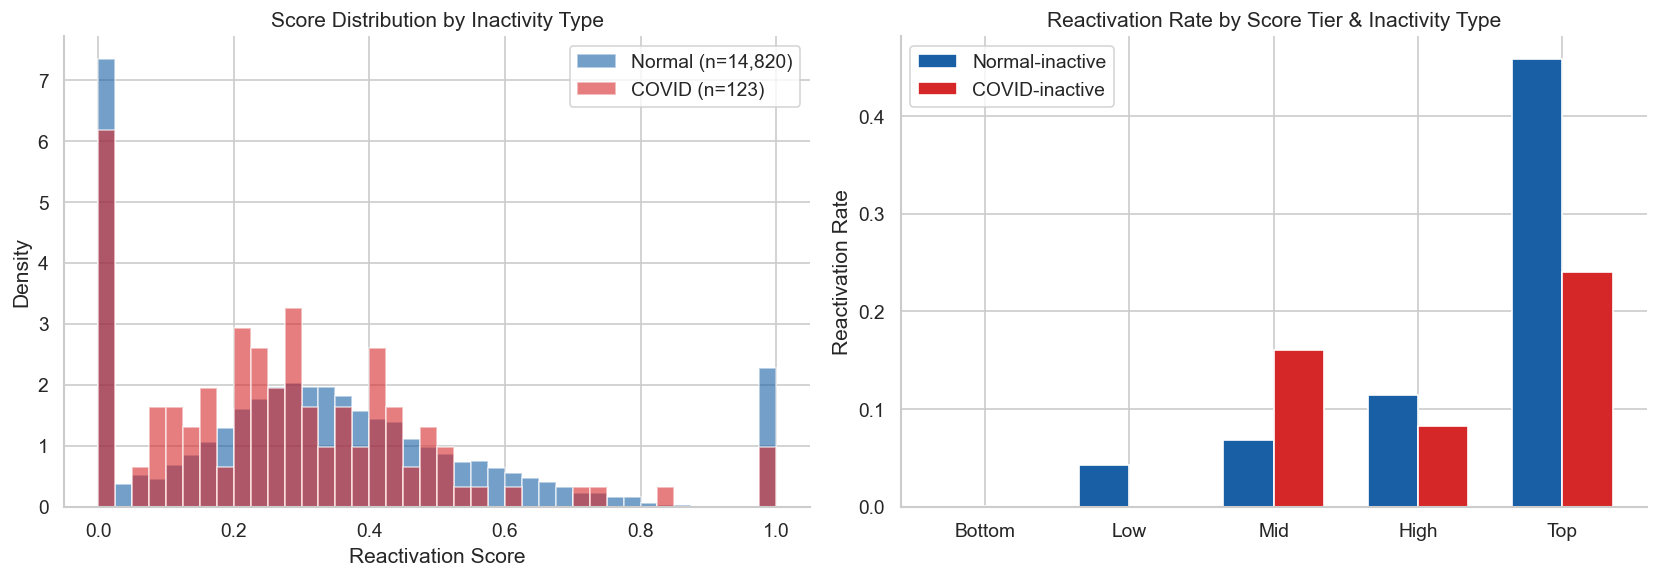

=== STRATEGIC SUMMARY ===
  COVID-inactive clients represent 0.8% of the inactive base.
  They reactivate at 0.7x the rate of normally-inactive clients.
  → COVID compounded genuine disengagement. These clients may need stronger
    incentives to return.

  The model scores them similarly (delta=-0.050),
  suggesting a unified campaign may work, but messaging could differ.


In [25]:
# ══════════════════════════════════════════════════════════════════════════
# COVID-INACTIVE vs. NORMALLY-INACTIVE — GROUP COMPARISON
# ══════════════════════════════════════════════════════════════════════════

# Split clients into two groups based on the covid_sensitive flag
covid_mask = model['covid_sensitive'] == 1
n_covid = covid_mask.sum()
n_normal = (~covid_mask).sum()

print(f'COVID-inactive clients:    {n_covid:>6,}  ({n_covid/len(model)*100:.1f}%)')
print(f'Normally-inactive clients: {n_normal:>6,}  ({n_normal/len(model)*100:.1f}%)')
print()

# ── 1. REACTIVATION RATES ─────────────────────────────────────────────────
react_covid  = y[covid_mask].mean()
react_normal = y[~covid_mask].mean()
react_overall = y.mean()

print('=== REACTIVATION RATES ===')
print(f'  COVID-inactive:    {react_covid:.1%}')
print(f'  Normally-inactive: {react_normal:.1%}')
print(f'  Overall:          {react_overall:.1%}')
print(f'  Difference:       {react_covid - react_normal:+.1%} pp')
print()

# ── 2. CLIENT PROFILE COMPARISON ──────────────────────────────────────────
profile_features = [
    'N_EMPLOYEES', 'ECONOMIC_POT', 'total_amount_spent',
    'freq_n_transactions', 'tenure_months'
]
profile_rows = []
for feat in profile_features:
    if feat in model.columns:
        profile_rows.append({
            'Feature': feat,
            'COVID-inactive (median)': model.loc[covid_mask, feat].median(),
            'Normal-inactive (median)': model.loc[~covid_mask, feat].median(),
            'Ratio (COVID/Normal)': round(
                model.loc[covid_mask, feat].median() /
                max(model.loc[~covid_mask, feat].median(), 0.001), 2
            )
        })

print('=== CLIENT PROFILE (medians) ===')
print(pd.DataFrame(profile_rows).to_string(index=False))
print()

# ── 3. BEHAVIORAL DIFFERENCES ────────────────────────────────────────────
behavior_features = [
    'average_amount_spent', 'n_distinct_channels', 'n_product_families',
    'tool_ratio', 'months_since_last_purchase', 'avg_purchase_gap',
    'spending_trend', 'cancellation_rate', 'spend_per_active_month',
    'family_concentration', 'item_concentration'
]
behavior_rows = []
for feat in behavior_features:
    if feat in model.columns:
        med_c = model.loc[covid_mask, feat].median()
        med_n = model.loc[~covid_mask, feat].median()
        behavior_rows.append({
            'Feature': feat,
            'COVID-inactive': round(med_c, 3),
            'Normal-inactive': round(med_n, 3),
            'Diff %': round((med_c - med_n) / max(abs(med_n), 0.001) * 100, 1)
        })

print('=== BEHAVIORAL DIFFERENCES (medians) ===')
print(pd.DataFrame(behavior_rows).to_string(index=False))
print()

# ── 4. CATEGORICAL PROFILE ───────────────────────────────────────────────
print('=== TOP SECTORS BY GROUP ===')
# Reconstruct trade sector from clients_churn
_sectors = clients_churn.set_index('CLIENT_ID')['TRADE SECTOR']
_model_ids = clients_churn.sort_values('CLIENT_ID', ascending=True)['CLIENT_ID'].values
_sector_series = pd.Series(_sectors.loc[_model_ids].values, index=model.index)

print('\nCOVID-inactive — top 5 sectors:')
print(_sector_series[covid_mask].value_counts().head().to_string())
print('\nNormally-inactive — top 5 sectors:')
print(_sector_series[~covid_mask].value_counts().head().to_string())
print()

# ── 5. MODEL SCORE DISTRIBUTION ──────────────────────────────────────────
scores_covid  = best_probs[covid_mask]
scores_normal = best_probs[~covid_mask]

print('=== MODEL SCORE DISTRIBUTION ===')
print(f'  COVID-inactive:    mean={scores_covid.mean():.3f}  median={np.median(scores_covid):.3f}  std={scores_covid.std():.3f}')
print(f'  Normal-inactive:   mean={scores_normal.mean():.3f}  median={np.median(scores_normal):.3f}  std={scores_normal.std():.3f}')
print()

# Score distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(scores_normal, bins=40, alpha=0.6, color='#185FA5', label=f'Normal (n={n_normal:,})', density=True)
axes[0].hist(scores_covid, bins=40, alpha=0.6, color='#D62728', label=f'COVID (n={n_covid:,})', density=True)
axes[0].set_xlabel('Reactivation Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Inactivity Type')
axes[0].legend()

# Reactivation rate by score decile, split by group
decile_rows = []
for group_name, mask in [('COVID-inactive', covid_mask), ('Normal-inactive', ~covid_mask)]:
    g_scores = best_probs[mask]
    g_target = y[mask]
    deciles = pd.qcut(g_scores, 5, labels=['Bottom','Low','Mid','High','Top'], duplicates='drop')
    for d in deciles.unique():
        d_mask = deciles == d
        decile_rows.append({
            'Group': group_name,
            'Score tier': str(d),
            'n': int(d_mask.sum()),
            'React. rate': round(float(g_target[d_mask].mean()), 3),
            'Avg score': round(float(g_scores[d_mask].mean()), 3)
        })

decile_df = pd.DataFrame(decile_rows)
print('=== REACTIVATION BY SCORE TIER & GROUP ===')
print(decile_df.to_string(index=False))
print()

# Bar chart
tier_order = ['Bottom','Low','Mid','High','Top']
covid_rates = decile_df[decile_df['Group']=='COVID-inactive'].set_index('Score tier').reindex(tier_order)['React. rate']
normal_rates = decile_df[decile_df['Group']=='Normal-inactive'].set_index('Score tier').reindex(tier_order)['React. rate']
x = np.arange(len(tier_order))
w = 0.35
axes[1].bar(x - w/2, normal_rates, w, color='#185FA5', label='Normal-inactive')
axes[1].bar(x + w/2, covid_rates, w, color='#D62728', label='COVID-inactive')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_order)
axes[1].set_ylabel('Reactivation Rate')
axes[1].set_title('Reactivation Rate by Score Tier & Inactivity Type')
axes[1].legend()
plt.tight_layout()
plt.show()

# ── 6. STRATEGIC SUMMARY ─────────────────────────────────────────────────
print('=== STRATEGIC SUMMARY ===')
print(f'  COVID-inactive clients represent {n_covid/len(model)*100:.1f}% of the inactive base.')
if react_covid > react_normal:
    print(f'  They reactivate at {react_covid/react_normal:.1f}x the rate of normally-inactive clients.')
    print(f'  → These are LOWER-HANGING FRUIT: they likely stopped buying due to external')
    print(f'    constraints, not dissatisfaction. A lighter-touch campaign may suffice.')
else:
    print(f'  They reactivate at {react_covid/react_normal:.1f}x the rate of normally-inactive clients.')
    print(f'  → COVID compounded genuine disengagement. These clients may need stronger')
    print(f'    incentives to return.')
print()
if abs(scores_covid.mean() - scores_normal.mean()) > 0.05:
    print(f'  The model scores them differently (delta={scores_covid.mean()-scores_normal.mean():+.3f}),')
    print(f'  suggesting different campaign strategies are warranted.')
else:
    print(f'  The model scores them similarly (delta={scores_covid.mean()-scores_normal.mean():+.3f}),')
    print(f'  suggesting a unified campaign may work, but messaging could differ.')


## Scoring & Campaign Prioritisation

Assigns every inactive client a reactivation score and sorts them into priority tiers:

| Tier | Clients |
|------|---------|
| Very High | Top 5% |
| High | 80th–95th percentile |
| Medium | 50th–80th percentile |
| Low | Bottom 50% |

Tiers are based on relative ranking (quantiles), not raw model probabilities.

In [26]:
# final_clients_churn (inactive clients) already defined in Cell 18
scores_df = pd.DataFrame({
    'CLIENT_ID'          : final_clients_churn['CLIENT_ID'].values,
    'reactivation_score' : best_probs,
    'target'             : y.values
})

# Add the selected model features (aligned by index from `model` DataFrame)
for feat in SELECTED_NUMERIC + SELECTED_CATEGORICAL:
    scores_df[feat] = model[feat].values

# Add context columns from the clients table
scores_df = scores_df.merge(
    clients[['CLIENT_ID', 'ECONOMIC_POT', 'REGION', 'TRADE SECTOR']],
    on='CLIENT_ID', how='left'
)

# Quantile-based tiers: ranks clients relative to each other, not on raw scores.
# Use rank-based assignment to avoid pd.qcut failures when scores have many ties.
score_rank = scores_df['reactivation_score'].rank(method='first', pct=True)
scores_df['priority_tier'] = pd.cut(
    score_rank,
    bins=[0, 0.50, 0.80, 0.95, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High'],
    include_lowest=True,
)

# Recommended flag (Very High + High = top ~20%)
scores_df['recommended'] = scores_df['priority_tier'].isin(['Very High', 'High'])

scores_df = scores_df.sort_values('reactivation_score', ascending=False).reset_index(drop=True)

tier_boundaries = scores_df.groupby('priority_tier', observed=False)['reactivation_score'].agg(['min','max','count'])
print()

# --- Tier summary ---
baseline_rate = y.mean()

tier_summary = (
    scores_df.groupby('priority_tier', observed=False)
    .agg(
        n_clients       = ('CLIENT_ID',           'count'),
        reactivation_rate = ('target',             'mean'),
        avg_score       = ('reactivation_score',   'mean'),
        total_eco_pot   = ('ECONOMIC_POT',         'sum')
    )
    .sort_values('avg_score', ascending=False)
)

tier_summary['reactivation_vs_baseline'] = tier_summary['reactivation_rate'] / baseline_rate
tier_summary['pct_of_inactive_base']       = tier_summary['n_clients'] / len(scores_df)

print('Campaign tier summary:')
print(tier_summary)


Tier score boundaries (quantile-based):
                    min       max  count
priority_tier                           
Low            0.000000  0.300591   7471
Medium         0.300605  0.496300   4483
High           0.496538  1.000000   2241
Very High      1.000000  1.000000    748

Score distribution:
count    14943.000000
mean         0.324206
std          0.256641
min          0.000000
25%          0.143843
50%          0.300605
75%          0.448658
max          1.000000
Name: reactivation_score, dtype: float64
Campaign tier summary:
               n_clients  reactivation_rate  avg_score  total_eco_pot  \
priority_tier                                                           
Very High            748           1.000000   1.000000     3311365.40   
High                2241           0.276662   0.625599    11130490.81   
Medium              4483           0.101271   0.385845    22140356.46   
Low                 7471           0.029715   0.129152    37439795.74   

              

## Bonus Visualisations

Additional charts built from existing data, each answering a specific business or modelling question.

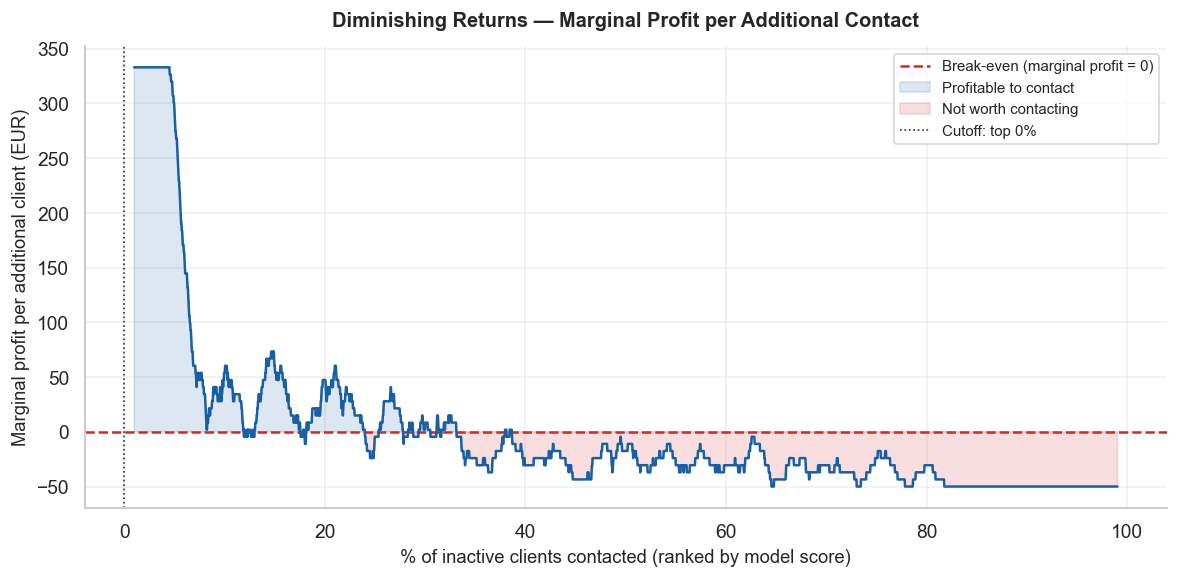


💬 Marginal profit turns negative at ~0% of clients contacted. Beyond this point, each additional contact costs more than it returns.


In [34]:
# ── VIZ 6: Marginal ROI Curve — When to Stop Contacting ──
# Answers: "At what point does contacting the next client stop being worth it?"

# Marginal profit = profit change from contacting one more client
marginal_profit = np.diff(eval_df['profit'].values, prepend=0)

# Smooth with rolling average for readability
window = max(1, N // 50)
marginal_smooth = pd.Series(marginal_profit).rolling(window, center=True).mean().values

fig, ax = plt.subplots(figsize=(10, 5))
pct_range = eval_df['k_pct'].values * 100

ax.plot(pct_range, marginal_smooth, color=BLUE, linewidth=1.5, zorder=3)
ax.axhline(0, color=RED, linestyle='--', linewidth=1.5, label='Break-even (marginal profit = 0)', zorder=2)
ax.fill_between(pct_range, marginal_smooth, 0,
                where=marginal_smooth > 0, alpha=0.15, color=BLUE, label='Profitable to contact')
ax.fill_between(pct_range, marginal_smooth, 0,
                where=marginal_smooth <= 0, alpha=0.15, color=RED, label='Not worth contacting')

# Find where marginal profit crosses zero
cross_idx = np.where(np.diff(np.sign(marginal_smooth)))[0]
if len(cross_idx) > 0:
    first_cross = cross_idx[0]
    cross_pct = pct_range[first_cross]
    ax.axvline(cross_pct, color='#333333', linestyle=':', linewidth=1,
               label=f'Cutoff: top {cross_pct:.0f}%')

ax.set_xlabel('% of inactive clients contacted (ranked by model score)', fontsize=11)
ax.set_ylabel(f'Marginal profit per additional client (EUR)', fontsize=11)
ax.set_title('Diminishing Returns — Marginal Profit per Additional Contact',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if len(cross_idx) > 0:
else:

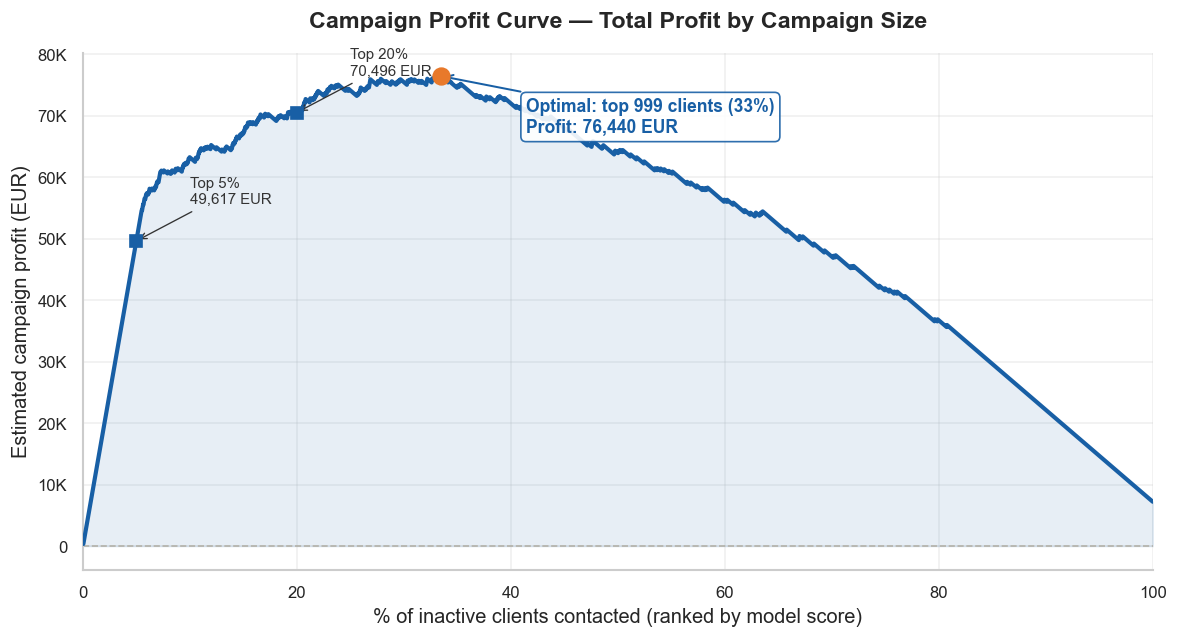


💬 Presenter note: "Profit climbs steeply at first — the model's top-ranked clients are almost all true reactivators. It peaks at 999 contacts (33% of the base) with an estimated 76,440 EUR profit. Beyond that, diminishing returns eat into the gains."


In [38]:
# ── VIZ 10: Profit Curve — Where Is the Sweet Spot? ──
# Answers: "How does total profit change as we widen the campaign?"
# Visualises the ROI table as a curve so the optimal campaign size jumps out.

fig, ax = plt.subplots(figsize=(10, 5.5))

pct_range = eval_df['k_pct'].values * 100
profit_vals = eval_df['profit'].values

# Main profit curve
ax.plot(pct_range, profit_vals, color=BLUE, linewidth=2.5, zorder=3)
ax.fill_between(pct_range, profit_vals, 0,
                where=profit_vals > 0, alpha=0.10, color=BLUE, zorder=1)
ax.fill_between(pct_range, profit_vals, 0,
                where=profit_vals <= 0, alpha=0.10, color=RED, zorder=1)

# Break-even line
ax.axhline(0, color=GRAY, linestyle='--', linewidth=1, zorder=2)

# Mark the optimal K (peak profit)
if peak_k is not None:
    peak_pct = peak_k / N * 100
    ax.plot(peak_pct, peak_profit, 'o', color=ORANGE, markersize=10, zorder=5)
    ax.annotate(
        f'Optimal: top {peak_k} clients ({peak_pct:.0f}%)\n'
        f'Profit: {peak_profit:,.0f} EUR',
        xy=(peak_pct, peak_profit),
        xytext=(peak_pct + 8, peak_profit - peak_profit * 0.12),
        fontsize=FONT_NOTE, fontweight='bold', color=BLUE,
        arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=BLUE, alpha=0.9),
    )

# Mark strategic campaign sizes
for label, k_val in [('Top 5%', int(0.05 * N)), ('Top 20%', int(0.20 * N))]:
    if 0 < k_val < N:
        pct_val = k_val / N * 100
        profit_val = eval_df.iloc[k_val - 1]['profit']
        ax.plot(pct_val, profit_val, 's', color=BLUE, markersize=7, zorder=4)
        ax.annotate(
            f'{label}\n{profit_val:,.0f} EUR',
            xy=(pct_val, profit_val),
            xytext=(pct_val + 5, profit_val + peak_profit * 0.08),
            fontsize=9, color='#333333',
            arrowprops=dict(arrowstyle='->', color='#333333', lw=0.8),
        )

ax.set_xlabel('% of inactive clients contacted (ranked by model score)',
              fontsize=FONT_LABEL)
ax.set_ylabel('Estimated campaign profit (EUR)', fontsize=FONT_LABEL)
ax.set_title('Campaign Profit Curve \u2014 Total Profit by Campaign Size',
             fontsize=FONT_TITLE, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:,.0f}K' if abs(x) >= 1000 else f'{x:,.0f}'))
ax.set_xlim(0, 100)
ax.tick_params(labelsize=FONT_TICK)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

if peak_k is not None:


## Export

Saves the final scored client list as `reactivation_scored_clients.csv`:
- Client ID, reactivation score (0–1), priority tier, recommended flag
- All selected model features (explains why each client scored as they did)
- Region and trade sector (campaign planning context)


In [39]:
output_cols = (
    ['CLIENT_ID', 'reactivation_score', 'priority_tier', 'recommended']
    + SELECTED_NUMERIC + SELECTED_CATEGORICAL
    + ['REGION', 'TRADE SECTOR']
)

output_df = scores_df[output_cols].copy()
output_df = output_df.rename(columns={'TRADE SECTOR': 'TRADE_SECTOR'})

output_df.to_csv('reactivation_scored_clients.csv', index=False)

print(f'Exported {len(output_df):,} scored clients to reactivation_scored_clients.csv')
print(f'\nTop 10 clients:')
print(output_df.head(10))


Exported 14,943 scored clients to reactivation_scored_clients.csv
Columns (15): ['CLIENT_ID', 'reactivation_score', 'priority_tier', 'recommended', 'n_zero_tranx', 'cancellation_rate', 'n_canc', 'avg_purchase_gap', 'months_active', 'months_since_last_purchase', 'tenure_months', 'freq_n_transactions', 'main_family', 'REGION', 'TRADE_SECTOR']

Top 10 clients:
  CLIENT_ID  reactivation_score priority_tier  recommended  n_zero_tranx  \
0  00081215                 1.0     Very High         True             1   
1  00039090                 1.0     Very High         True             3   
2  00039733                 1.0     Very High         True             0   
3  00039688                 1.0     Very High         True             0   
4  00039664                 1.0     Very High         True             4   
5  00039564                 1.0     Very High         True             0   
6  00039531                 1.0     Very High         True             1   
7  00039467                 1.0 